# LAB: Dimensionality Reduction
### CPE 342: Machine Learning (Semester 1/2024)
**Department of Computer Engineering, Faculty of Engineering**  
**King Mongkut's University of Technology Thonburi (KMUTT)**

---

### 👥 ผู้จัดทำ (Group Members):
1. **นายวิศิษฐ์ สุวรรณเนาว์ (Wisit Suwannao)** — รหัสนักศึกษา: `67070501042`
2. **นายนัธทวัฒน์ ปริมสิริคุณาวุฒิ (Natthawat Primsirikunawut)** — รหัสนักศึกษา: `67070501027`

**Instructor:** Dr. Boonyarit Changaival  
**Academic Year:** 2024 / 2026

**Load necessary packages and apply custom configurations**

In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter('ignore', ValueWarning)

%config InlineBackend.figure_formats = {'png', 'retina'}

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import random
import numpy as np
import scipy as sp
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import sklearn as skl
from sklearn.preprocessing import StandardScaler
from platform import python_version

# Set reproducible seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Python version:', python_version())
print('Numpy version:', np.__version__)
print('Scipy version:', sp.__version__)
print('Pandas version:', pd.__version__)
print('Matplotlib version:', mpl.__version__)
print('Seaborn version:', sns.__version__)
print('Scikit-learn version:', skl.__version__)

# Academic Publication Styling with Sarabun Font
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['font.sans-serif'] = ['Sarabun', 'TH Sarabun New', 'DejaVu Sans']
plt.rcParams['figure.figsize'] = (7, 6)
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

sns.set_style("whitegrid", {'axes.grid': False})

Python version: 3.11.16
Numpy version: 2.4.6
Scipy version: 1.17.1
Pandas version: 2.3.3
Matplotlib version: 3.11.2
Seaborn version: 0.13.2
Scikit-learn version: 1.9.1


# Part I: Linear PCA

**Create a dataset**   
rows = instances, columns = features/variables  

In [2]:
x1 = np.array([9, 15, 25, 14, 10, 18, 0, 16, 5, 19, 16, 20])
x2 = np.array([39, 56, 93, 61, 50, 75, 32, 85, 42, 70, 66, 80])

D = np.vstack((x1, x2)).T 
print("Dataset D (shape: {}):\n{}".format(D.shape, D))
print("Initial features: x1 (mean = {:.2f}), x2 (mean = {:.2f})".format(np.mean(x1), np.mean(x2)))

Dataset D (shape: (12, 2)):
[[ 9 39]
 [15 56]
 [25 93]
 [14 61]
 [10 50]
 [18 75]
 [ 0 32]
 [16 85]
 [ 5 42]
 [19 70]
 [16 66]
 [20 80]]
Initial features: x1 (mean = 13.92), x2 (mean = 62.42)


<font color='blue'>Make the dataset zero-mean by subtracting each column by its mean.

In [3]:
# Compute column-wise empirical mean
mean_D = np.mean(D, axis=0)

# Zero-mean centering
X = D - mean_D

print("Original Column Means (mu_x1, mu_x2):", mean_D)
print("Centered Data X (shape: {}):\n{}".format(X.shape, X))
print("Verification - Mean of X after centering:", np.round(np.mean(X, axis=0), 4))
assert np.allclose(np.mean(X, axis=0), 0.0), "Data must have exact zero mean!"

Original Column Means (mu_x1, mu_x2): [13.91666667 62.41666667]
Centered Data X (shape: (12, 2)):
[[ -4.91666667 -23.41666667]
 [  1.08333333  -6.41666667]
 [ 11.08333333  30.58333333]
 [  0.08333333  -1.41666667]
 [ -3.91666667 -12.41666667]
 [  4.08333333  12.58333333]
 [-13.91666667 -30.41666667]
 [  2.08333333  22.58333333]
 [ -8.91666667 -20.41666667]
 [  5.08333333   7.58333333]
 [  2.08333333   3.58333333]
 [  6.08333333  17.58333333]]
Verification - Mean of X after centering: [0. 0.]


<font color='blue'>Compute the sample covariance matrix $Z$ from the zero-mean data using `np.cov`.  
    
   
Use the option `rowvar=False` to treat the variables column-wise.  
The sum is divided by  $N-1$ by default (option `bias=False` or `ddof=1`)

In [4]:
# Compute sample covariance matrix with Bessel's correction (ddof=1)
Z = np.cov(X, rowvar=False, bias=False)

print("Sample Covariance Matrix Z (ddof=1):\n", Z)
print("\nIndividual Sample Variances:")
print(f"  Var(x1) = s11 = {Z[0, 0]:.4f}")
print(f"  Var(x2) = s22 = {Z[1, 1]:.4f}")
print(f"  Cov(x1, x2) = s12 = {Z[0, 1]:.4f}")
print(f"  Total Sample Variance (tr(Z)) = {np.trace(Z):.4f}")

Sample Covariance Matrix Z (ddof=1):
 [[ 47.71969697 122.9469697 ]
 [122.9469697  370.08333333]]

Individual Sample Variances:
  Var(x1) = s11 = 47.7197
  Var(x2) = s22 = 370.0833
  Cov(x1, x2) = s12 = 122.9470
  Total Sample Variance (tr(Z)) = 417.8030


<font color='blue'>Compute the eigenpairs of the covariance matrix $Z$ to get the principal components.  
Show the eigenvectors sorted by the largest eigenvalues first, and the corresponding eigenvalues.

In [5]:
# Compute eigenvalues and eigenvectors of covariance matrix Z
eigenvalues, eigenvectors = np.linalg.eig(Z)

# Sort in descending order of eigenvalues
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Sorted Eigenvalues (lambda_1 >= lambda_2):")
for i, val in enumerate(eigenvalues):
    print(f"  lambda_{i+1} = {val:.6f}")

print("\nCorresponding Eigenvectors (Principal Directions - Column-wise):")
for i in range(eigenvectors.shape[1]):
    p_vec = eigenvectors[:, i]
    print(f"  p_{i+1} = {p_vec}  (Euclidean Norm = {np.linalg.norm(p_vec):.4f})")

print("\nOrthogonality check (p1 . p2):", np.round(np.dot(eigenvectors[:, 0], eigenvectors[:, 1]), 6))

Sorted Eigenvalues (lambda_1 >= lambda_2):
  lambda_1 = 411.621854
  lambda_2 = 6.181176

Corresponding Eigenvectors (Principal Directions - Column-wise):
  p_1 = [-0.32008244 -0.94738969]  (Euclidean Norm = 1.0000)
  p_2 = [-0.94738969  0.32008244]  (Euclidean Norm = 1.0000)

Orthogonality check (p1 . p2): 0.0


<font color='blue'>Take $r=2$ principal components as the matrix `Pr`

In [6]:
r = 2
Pr = eigenvectors[:, :r]

print("Matrix Pr (Principal Components Matrix, shape: {}):\n{}".format(Pr.shape, Pr))
print("\nVerification of Orthonormality (Pr.T @ Pr = I):\n", np.round(Pr.T @ Pr, 4))
assert np.allclose(Pr.T @ Pr, np.eye(r)), "Pr must be strictly orthonormal!"

Matrix Pr (Principal Components Matrix, shape: (2, 2)):
[[-0.32008244 -0.94738969]
 [-0.94738969  0.32008244]]

Verification of Orthonormality (Pr.T @ Pr = I):
 [[1. 0.]
 [0. 1.]]


<font color='blue'>Transform the data to obtain the reduced-dimension data `Z` by multiplying  
    the zero-mean data $X$ to the matrix of principal components $Pr$.

In [7]:
# Project centered data X onto principal component directions Pr
Z_scores = X @ Pr

print("Transformed Data Z (PC Scores, shape: {}):\n{}".format(Z_scores.shape, Z_scores))
print("\nCovariance of PC Scores (should be diagonal with eigenvalues):\n", np.round(np.cov(Z_scores, rowvar=False), 4))
print("Empirical Variance of PC1 scores:", np.var(Z_scores[:, 0], ddof=1))
print("Empirical Variance of PC2 scores:", np.var(Z_scores[:, 1], ddof=1))

Transformed Data Z (PC Scores, shape: (12, 2)):
[[ 23.75844731  -2.83726457]
 [  5.73232788  -3.08020118]
 [-32.52191518  -0.71104768]
 [  1.31546186  -0.53239927]
 [ 13.01707825  -0.26374738]
 [-13.22832361   0.15919617]
 [ 33.27091715   3.44866555]
 [-22.06205564   5.2548    ]
 [ 22.19660801   1.91254153]
 [ -8.81145759  -2.38860574]
 [ -4.06165149  -0.82676644]
 [-18.60543696  -0.13517099]]

Covariance of PC Scores (should be diagonal with eigenvalues):
 [[411.6219   0.    ]
 [  0.       6.1812]]
Empirical Variance of PC1 scores: 411.62185421512334
Empirical Variance of PC2 scores: 6.181176087906935


<font color='blue'>Reverse-transform the data by multiplying the transformed data and the matrix of principal components. 

In [8]:
# Reverse-transformation (Reconstruction)
X_hat = Z_scores @ Pr.T
D_hat = X_hat + mean_D

recon_diff_X = np.linalg.norm(X - X_hat)
recon_diff_D = np.linalg.norm(D - D_hat)

print("Reverse-transformed Centered Data X_hat (shape: {}):\n{}".format(X_hat.shape, np.round(X_hat, 4)))
print("\nReconstructed Original Data D_hat (with mean added):\n", np.round(D_hat, 4))
print(f"\nFrobenius Norm of Error ||X - X_hat||_F: {recon_diff_X:.4e}")
print(f"Frobenius Norm of Error ||D - D_hat||_F: {recon_diff_D:.4e}")
assert np.allclose(X, X_hat, atol=1e-12), "Reverse transformation with r=2 must be exact!"
assert np.allclose(D, D_hat, atol=1e-12), "Reconstructed D_hat must match original D exactly!"

Reverse-transformed Centered Data X_hat (shape: (12, 2)):
[[ -4.9167 -23.4167]
 [  1.0833  -6.4167]
 [ 11.0833  30.5833]
 [  0.0833  -1.4167]
 [ -3.9167 -12.4167]
 [  4.0833  12.5833]
 [-13.9167 -30.4167]
 [  2.0833  22.5833]
 [ -8.9167 -20.4167]
 [  5.0833   7.5833]
 [  2.0833   3.5833]
 [  6.0833  17.5833]]

Reconstructed Original Data D_hat (with mean added):
 [[ 9. 39.]
 [15. 56.]
 [25. 93.]
 [14. 61.]
 [10. 50.]
 [18. 75.]
 [ 0. 32.]
 [16. 85.]
 [ 5. 42.]
 [19. 70.]
 [16. 66.]
 [20. 80.]]

Frobenius Norm of Error ||X - X_hat||_F: 1.2093e-14
Frobenius Norm of Error ||D - D_hat||_F: 4.3512e-15


<font color='blue'>Determine the variance explained by each principal component from the eigenvalues, 
the PVEs and the cumulative PVEs from the eigenvalues. 

Total Sample Variance: 417.8030
  PC1: Variance = 411.6219, PVE =  98.52%, Cumulative PVE =  98.52%
  PC2: Variance =   6.1812, PVE =   1.48%, Cumulative PVE = 100.00%


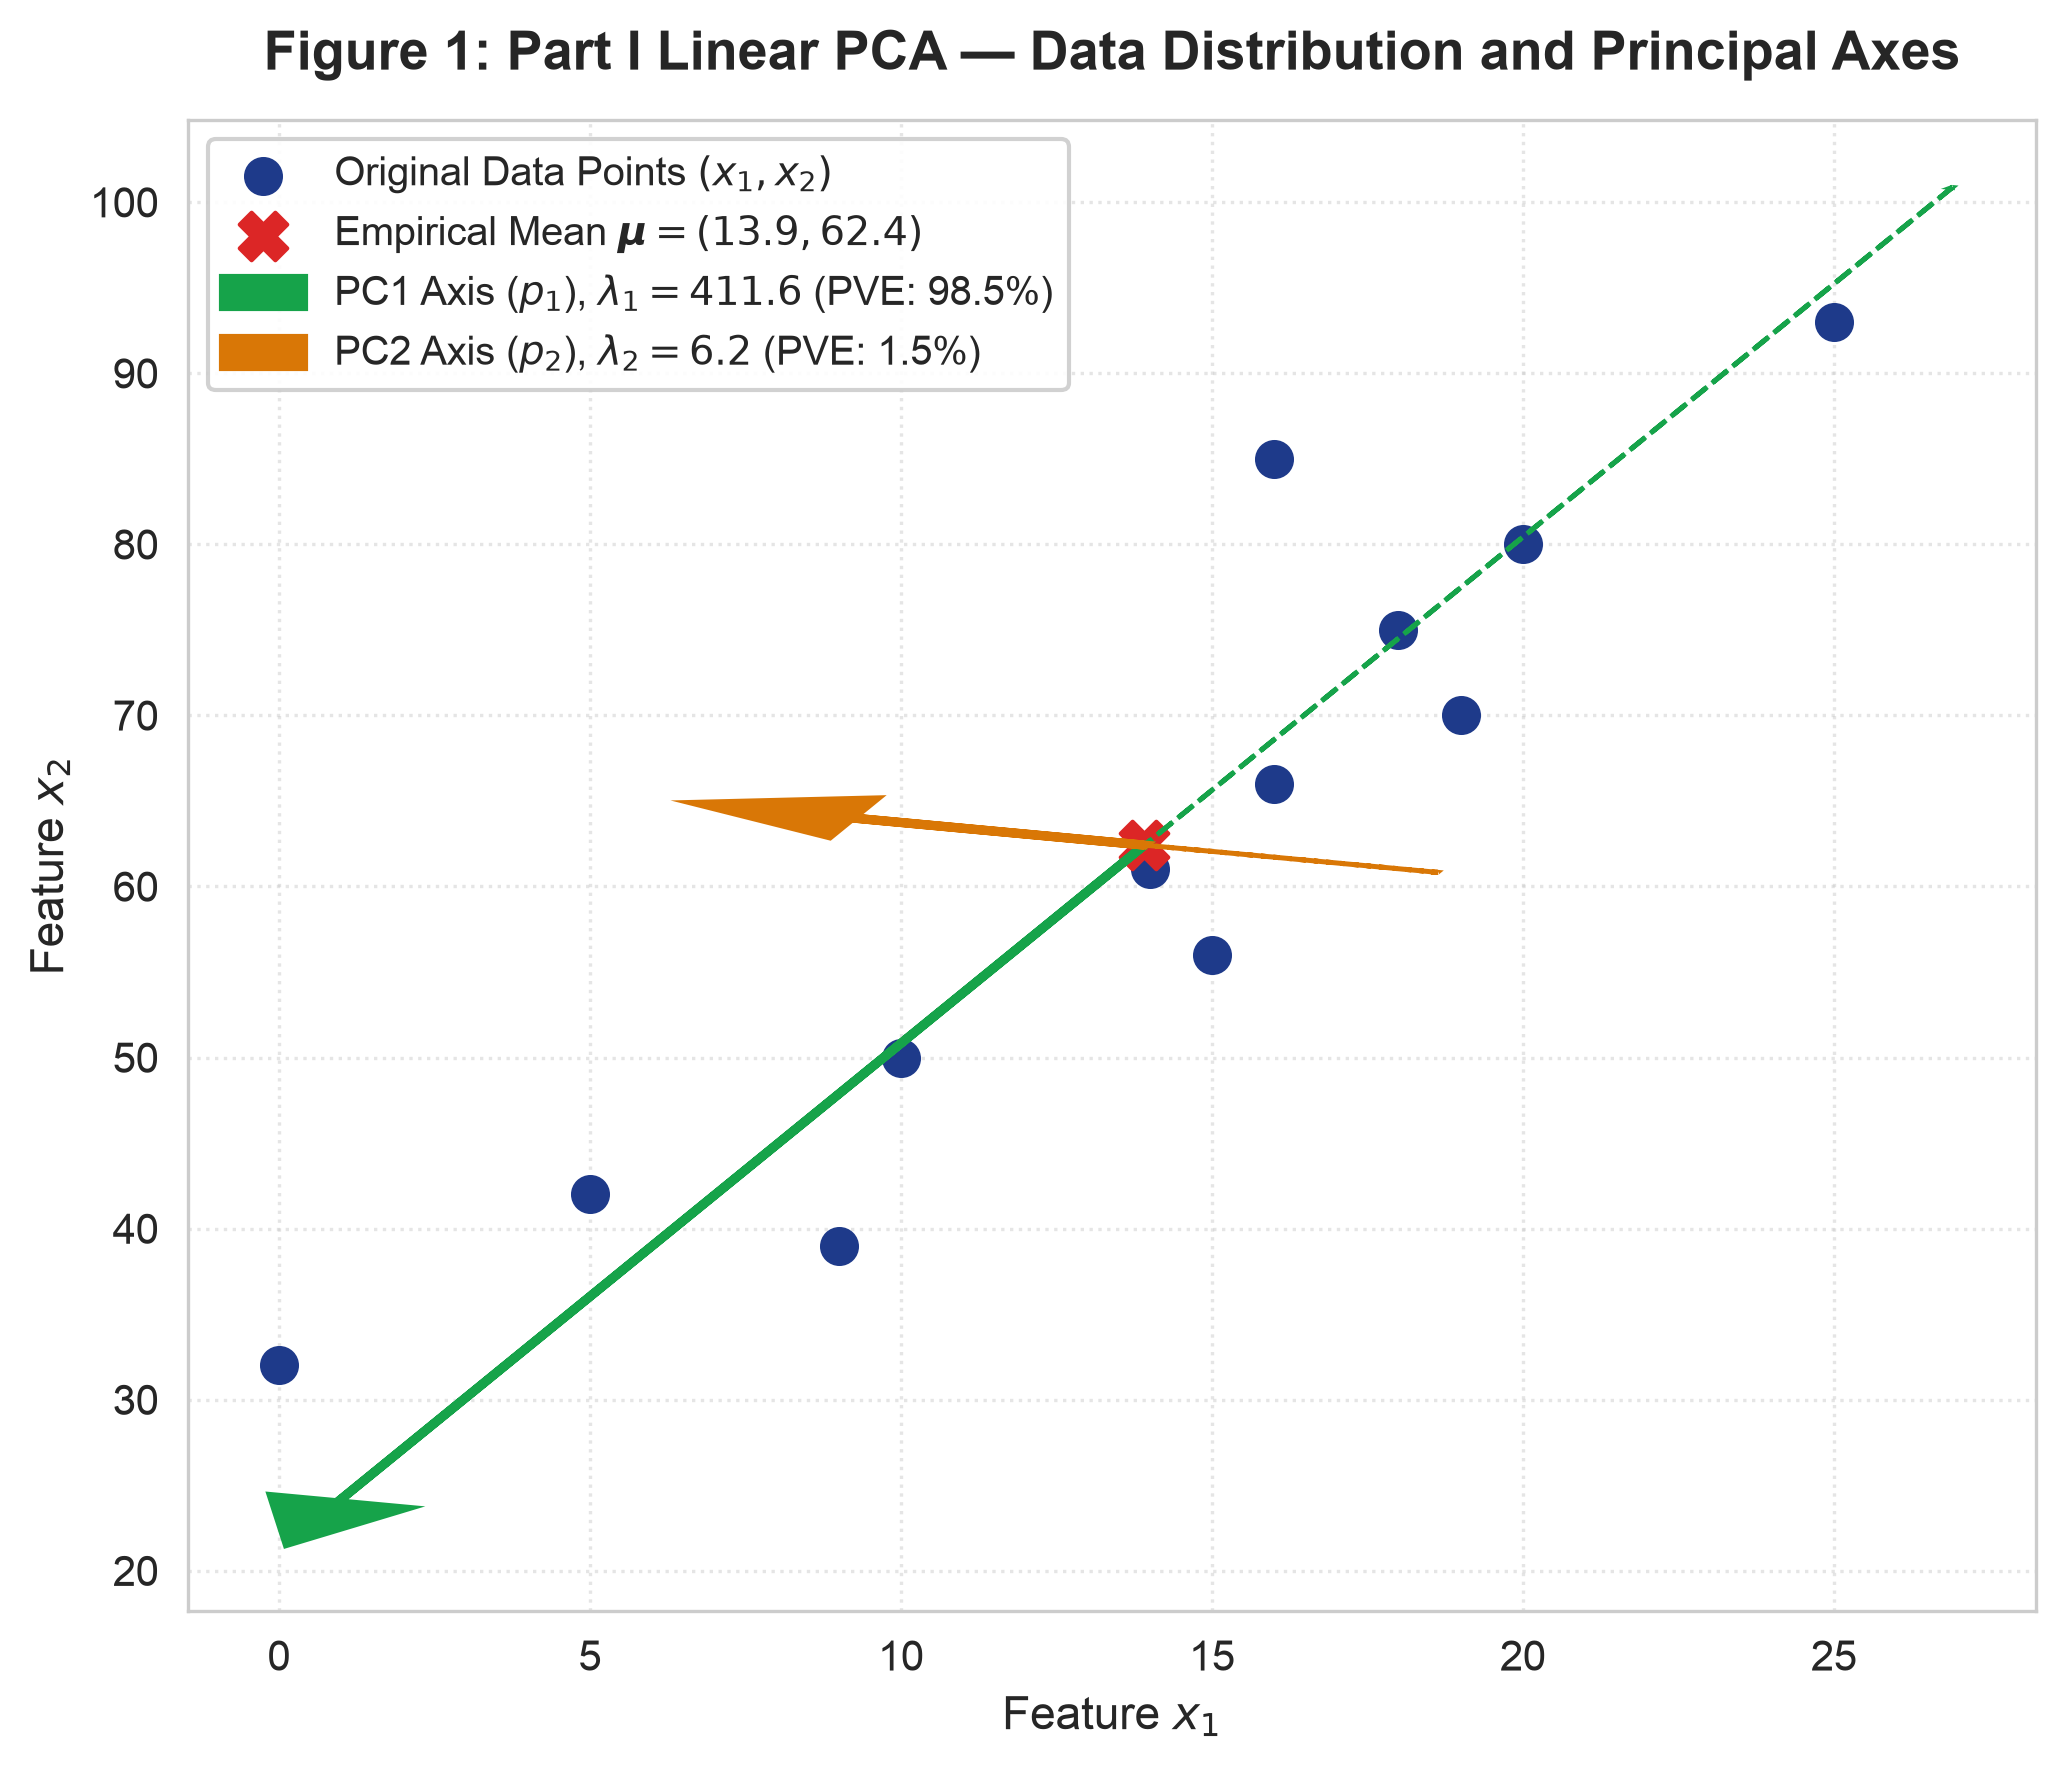

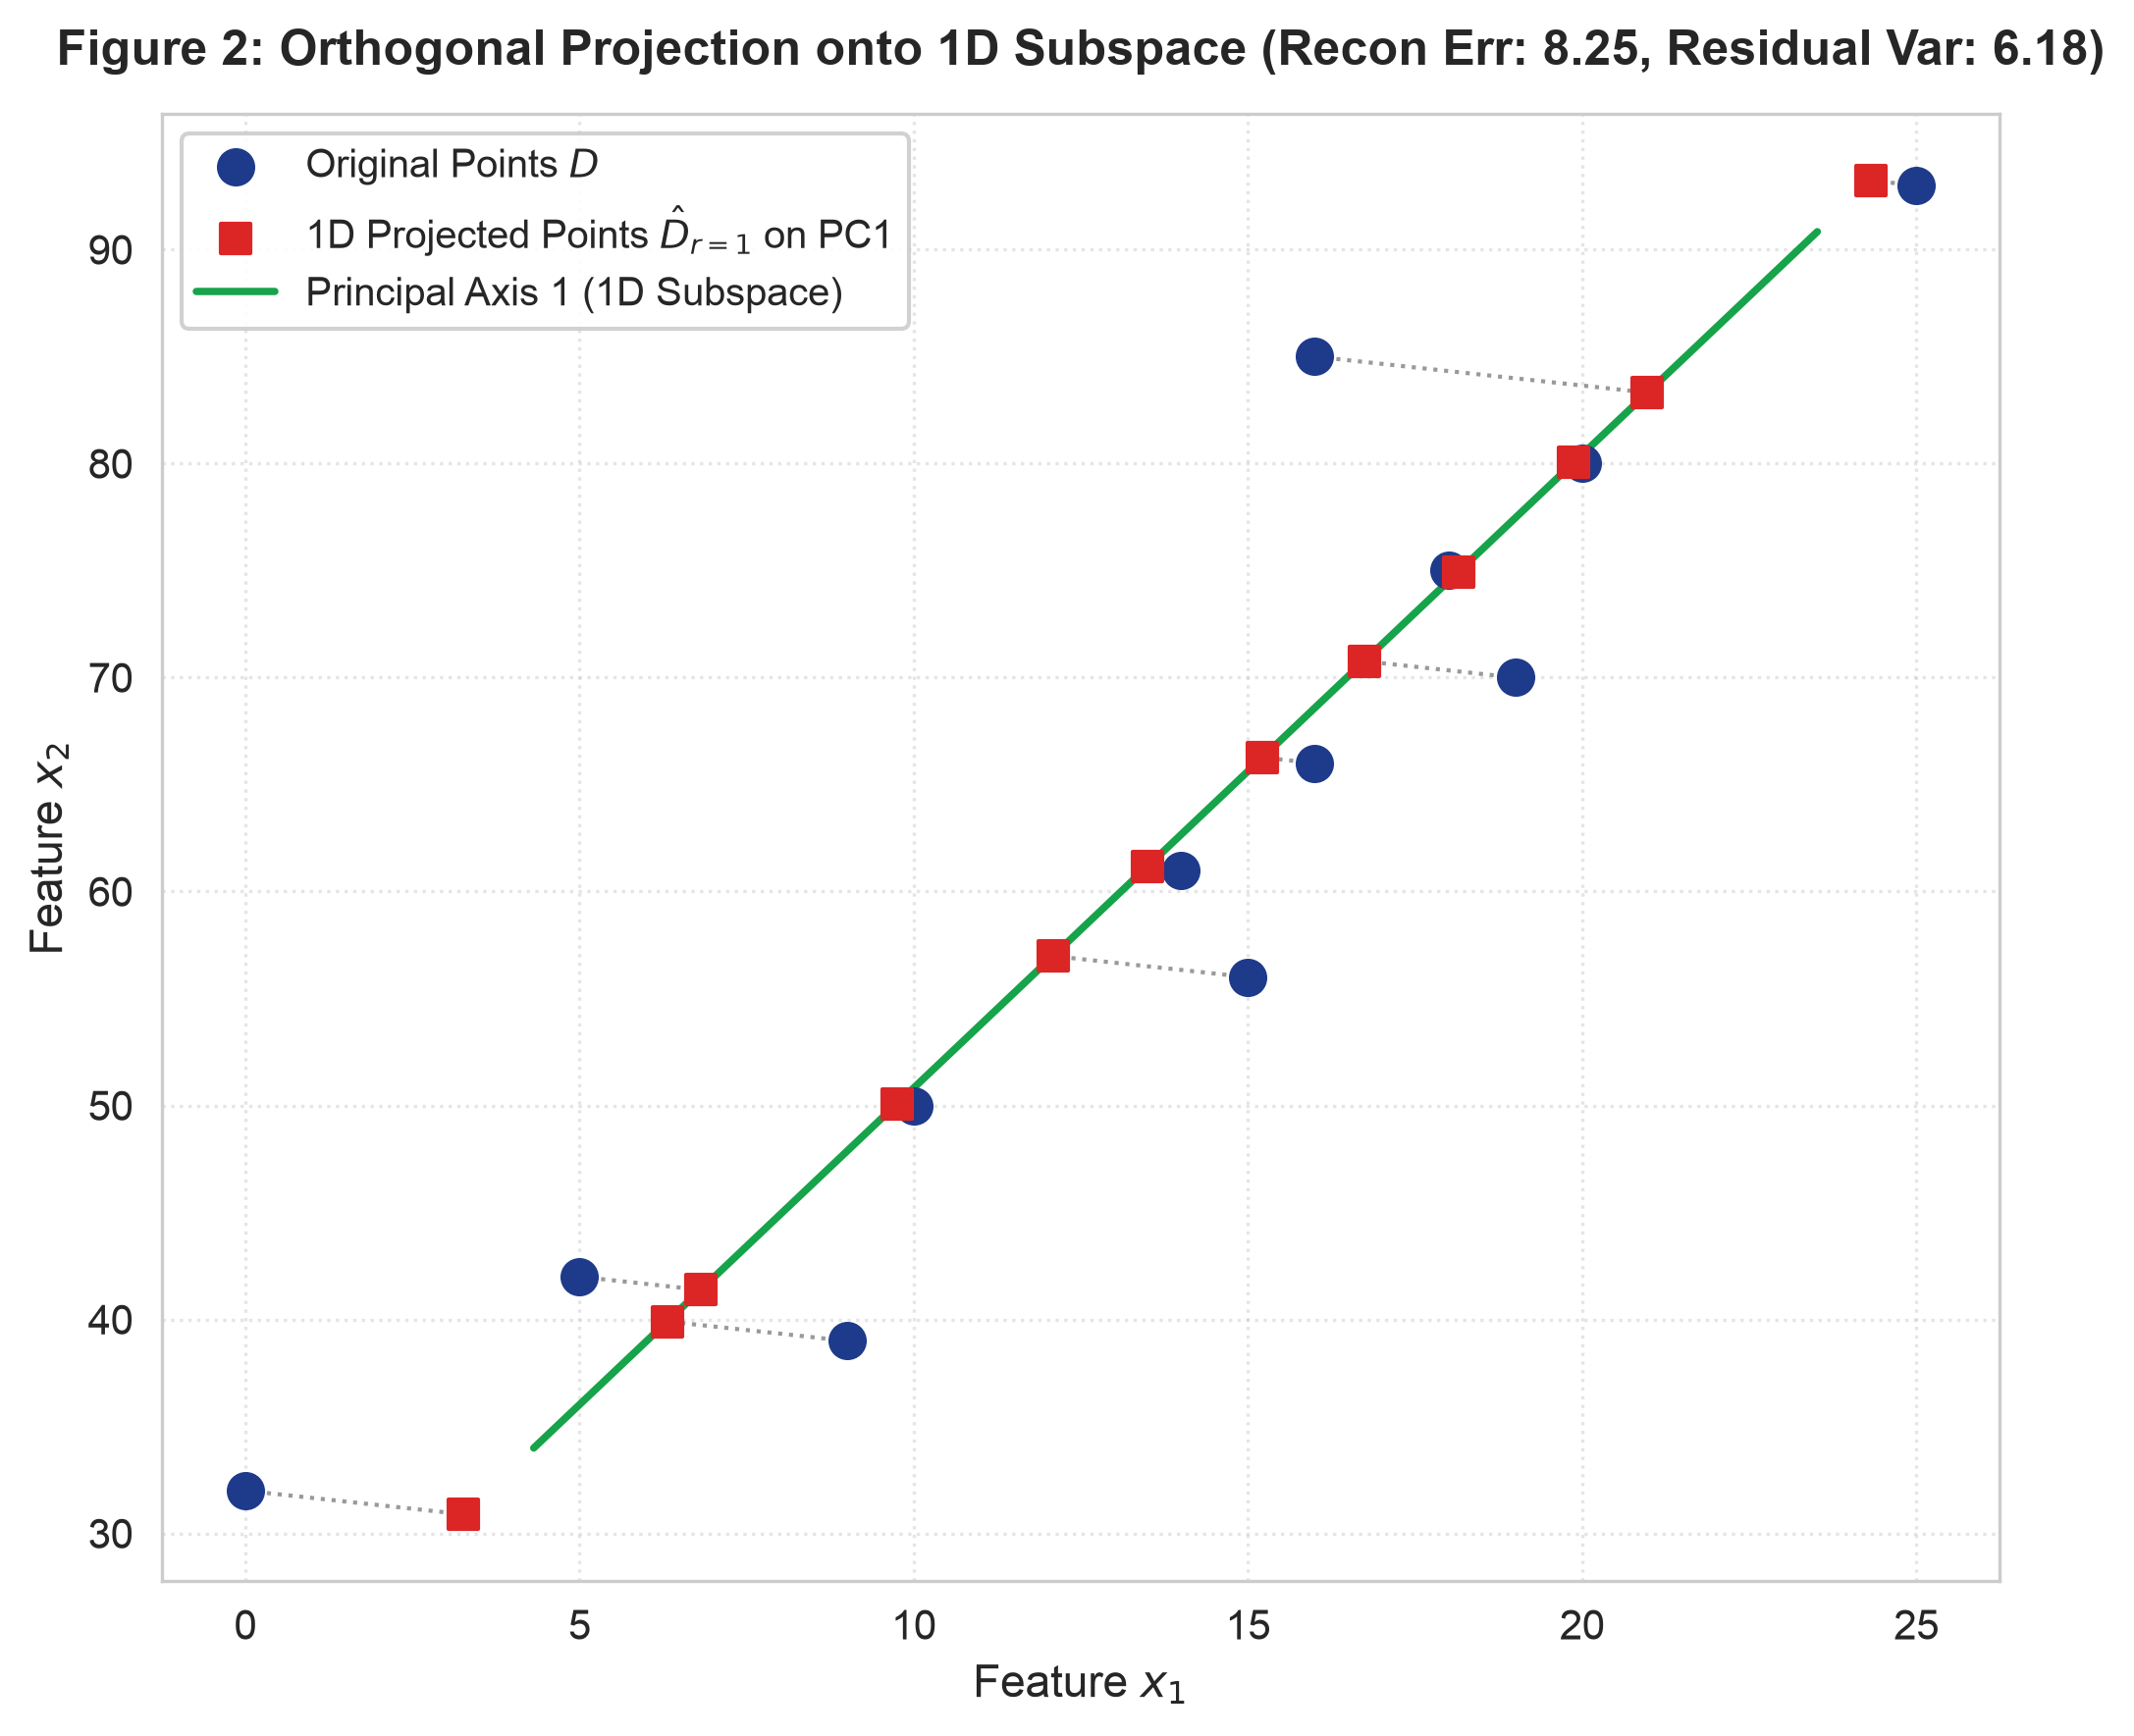

In [9]:
# Compute Variance Explained and PVE
var_explained = eigenvalues
total_variance = np.sum(eigenvalues)
pve = eigenvalues / total_variance
cum_pve = np.cumsum(pve)

print(f"Total Sample Variance: {total_variance:.4f}")
for i in range(len(eigenvalues)):
    print(f"  PC{i+1}: Variance = {var_explained[i]:8.4f}, PVE = {pve[i]*100:6.2f}%, Cumulative PVE = {cum_pve[i]*100:6.2f}%")

assert np.isclose(cum_pve[-1], 1.0), "Cumulative PVE must sum to 1.0!"

# =========================================================================
# FIGURE 1: 2D Geometry of Data Points and Principal Component Vectors
# =========================================================================
fig, ax = plt.subplots(figsize=(7, 6))
_ = ax.scatter(D[:, 0], D[:, 1], color='#1E3A8A', s=70, zorder=4, label='Original Data Points $(x_1, x_2)$')
_ = ax.scatter(mean_D[0], mean_D[1], color='#DC2626', s=130, marker='X', zorder=5, label=f'Empirical Mean $\\boldsymbol{{\\mu}} = ({mean_D[0]:.1f}, {mean_D[1]:.1f})$')

# Scale vectors by standard deviations (sqrt of eigenvalue)
scale_pc1 = 2.0 * np.sqrt(eigenvalues[0])
scale_pc2 = 2.0 * np.sqrt(eigenvalues[1])

_ = ax.arrow(mean_D[0], mean_D[1], eigenvectors[0, 0]*scale_pc1, eigenvectors[1, 0]*scale_pc1,
             head_width=2.2, head_length=2.5, fc='#16A34A', ec='#16A34A', lw=2.2, zorder=6,
             label=f'PC1 Axis ($p_1$), $\\lambda_1 = {eigenvalues[0]:.1f}$ (PVE: {pve[0]*100:.1f}%)')
_ = ax.arrow(mean_D[0], mean_D[1], -eigenvectors[0, 0]*scale_pc1, -eigenvectors[1, 0]*scale_pc1,
             fc='#16A34A', ec='#16A34A', lw=1.2, ls='--', zorder=6)

_ = ax.arrow(mean_D[0], mean_D[1], eigenvectors[0, 1]*scale_pc2, eigenvectors[1, 1]*scale_pc2,
             head_width=2.2, head_length=2.5, fc='#D97706', ec='#D97706', lw=2.2, zorder=6,
             label=f'PC2 Axis ($p_2$), $\\lambda_2 = {eigenvalues[1]:.1f}$ (PVE: {pve[1]*100:.1f}%)')
_ = ax.arrow(mean_D[0], mean_D[1], -eigenvectors[0, 1]*scale_pc2, -eigenvectors[1, 1]*scale_pc2,
             fc='#D97706', ec='#D97706', lw=1.2, ls='--', zorder=6)

_ = ax.set_title("Figure 1: Part I Linear PCA — Data Distribution and Principal Axes", fontsize=13, pad=12, fontweight='bold')
_ = ax.set_xlabel("Feature $x_1$", fontsize=11)
_ = ax.set_ylabel("Feature $x_2$", fontsize=11)
_ = ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper left', fontsize=9.5)
_ = ax.grid(True, linestyle=':', alpha=0.5)
_ = plt.tight_layout()
plt.savefig('plot_1_linear_pca_geometry.pdf', bbox_inches='tight')
plt.show()

# =========================================================================
# FIGURE 2: 1D Dimensionality Reduction & Projection Visualization
# =========================================================================
# 1D projection onto PC1 only (r=1)
P1 = eigenvectors[:, :1]
Z_1d = X @ P1
X_hat_1d = Z_1d @ P1.T
D_hat_1d = X_hat_1d + mean_D

fig, ax = plt.subplots(figsize=(7, 6))
_ = ax.scatter(D[:, 0], D[:, 1], color='#1E3A8A', s=70, zorder=4, label='Original Points $D$')
_ = ax.scatter(D_hat_1d[:, 0], D_hat_1d[:, 1], color='#DC2626', s=55, marker='s', zorder=5, label='1D Projected Points $\\hat{D}_{r=1}$ on PC1')

# Draw orthogonal projection lines
for orig, proj in zip(D, D_hat_1d):
    _ = ax.plot([orig[0], proj[0]], [orig[1], proj[1]], color='gray', linestyle=':', lw=1.0, alpha=0.8)

# Plot PC1 line
t_vals = np.linspace(-30, 30, 100)
line_pts = mean_D + np.outer(t_vals, eigenvectors[:, 0])
_ = ax.plot(line_pts[:, 0], line_pts[:, 1], color='#16A34A', lw=1.8, label='Principal Axis 1 (1D Subspace)')

recon_err_1d = np.linalg.norm(D - D_hat_1d)
residual_var = np.sum((D - D_hat_1d)**2) / (len(D) - 1)
_ = ax.set_title(f"Figure 2: Orthogonal Projection onto 1D Subspace (Recon Err: {recon_err_1d:.2f}, Residual Var: {residual_var:.2f})", fontsize=12, pad=12, fontweight='bold')
_ = ax.set_xlabel("Feature $x_1$", fontsize=11)
_ = ax.set_ylabel("Feature $x_2$", fontsize=11)
_ = ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper left', fontsize=9.5)
_ = ax.grid(True, linestyle=':', alpha=0.5)
_ = plt.tight_layout()
plt.savefig('plot_2_projection_reconstruction.pdf', bbox_inches='tight')
plt.show()

# Part II: Dimensionaltiy reduction with PCA

The dataset from sheet `MTCARS` in file `dimensionality-reduction.xlsx`. The dataset contains 11 columns:
- `mpg`: Miles per gallon (Fuel efficience)
- `cyl`: Number of cyclinders  
- `disp`: Displacement (Proxy to power generated by engine)  
- `hp`: Gross horse power  (Engine power output)
- `drat`: Rear axle ratio (# turns of the drive shaft for every one rotation of the wheel axle). 
          High ratio = More torque
- `wt`: Weight in 1000lbs
- `qsec`: 1/4 mile time (Fastest time to travel 1/4 mile in seconds)
- `vs`: Engine cylinder configuration (V-shape or Straight line)
- `am`: Transmission Type (Automatic or Manual)
- `gear`: Number of forward gears
- `carb`: Number of carburetors. Engines with higher displacement typically have higher barrel configuration

Load and explore the dataset

MTCARS Dataset Dimensions: (32, 11)
Column Names: ['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']

Summary Statistics (Raw Features):
          mpg    cyl    disp      hp   drat     wt   qsec     vs     am   gear  \
count  32.00  32.00   32.00   32.00  32.00  32.00  32.00  32.00  32.00  32.00   
mean   20.09   6.19  230.72  146.69   3.60   3.22  17.85   0.44   0.41   3.69   
std     6.03   1.79  123.94   68.56   0.53   0.98   1.79   0.50   0.50   0.74   
min    10.40   4.00   71.10   52.00   2.76   1.51  14.50   0.00   0.00   3.00   
25%    15.42   4.00  120.82   96.50   3.08   2.58  16.89   0.00   0.00   3.00   
50%    19.20   6.00  196.30  123.00   3.70   3.32  17.71   0.00   0.00   4.00   
75%    22.80   8.00  326.00  180.00   3.92   3.61  18.90   1.00   1.00   4.00   
max    33.90   8.00  472.00  335.00   4.93   5.42  22.90   1.00   1.00   5.00   

        carb  
count  32.00  
mean    2.81  
std     1.62  
min     1.00  
25%     2.00  
50%     2.00  

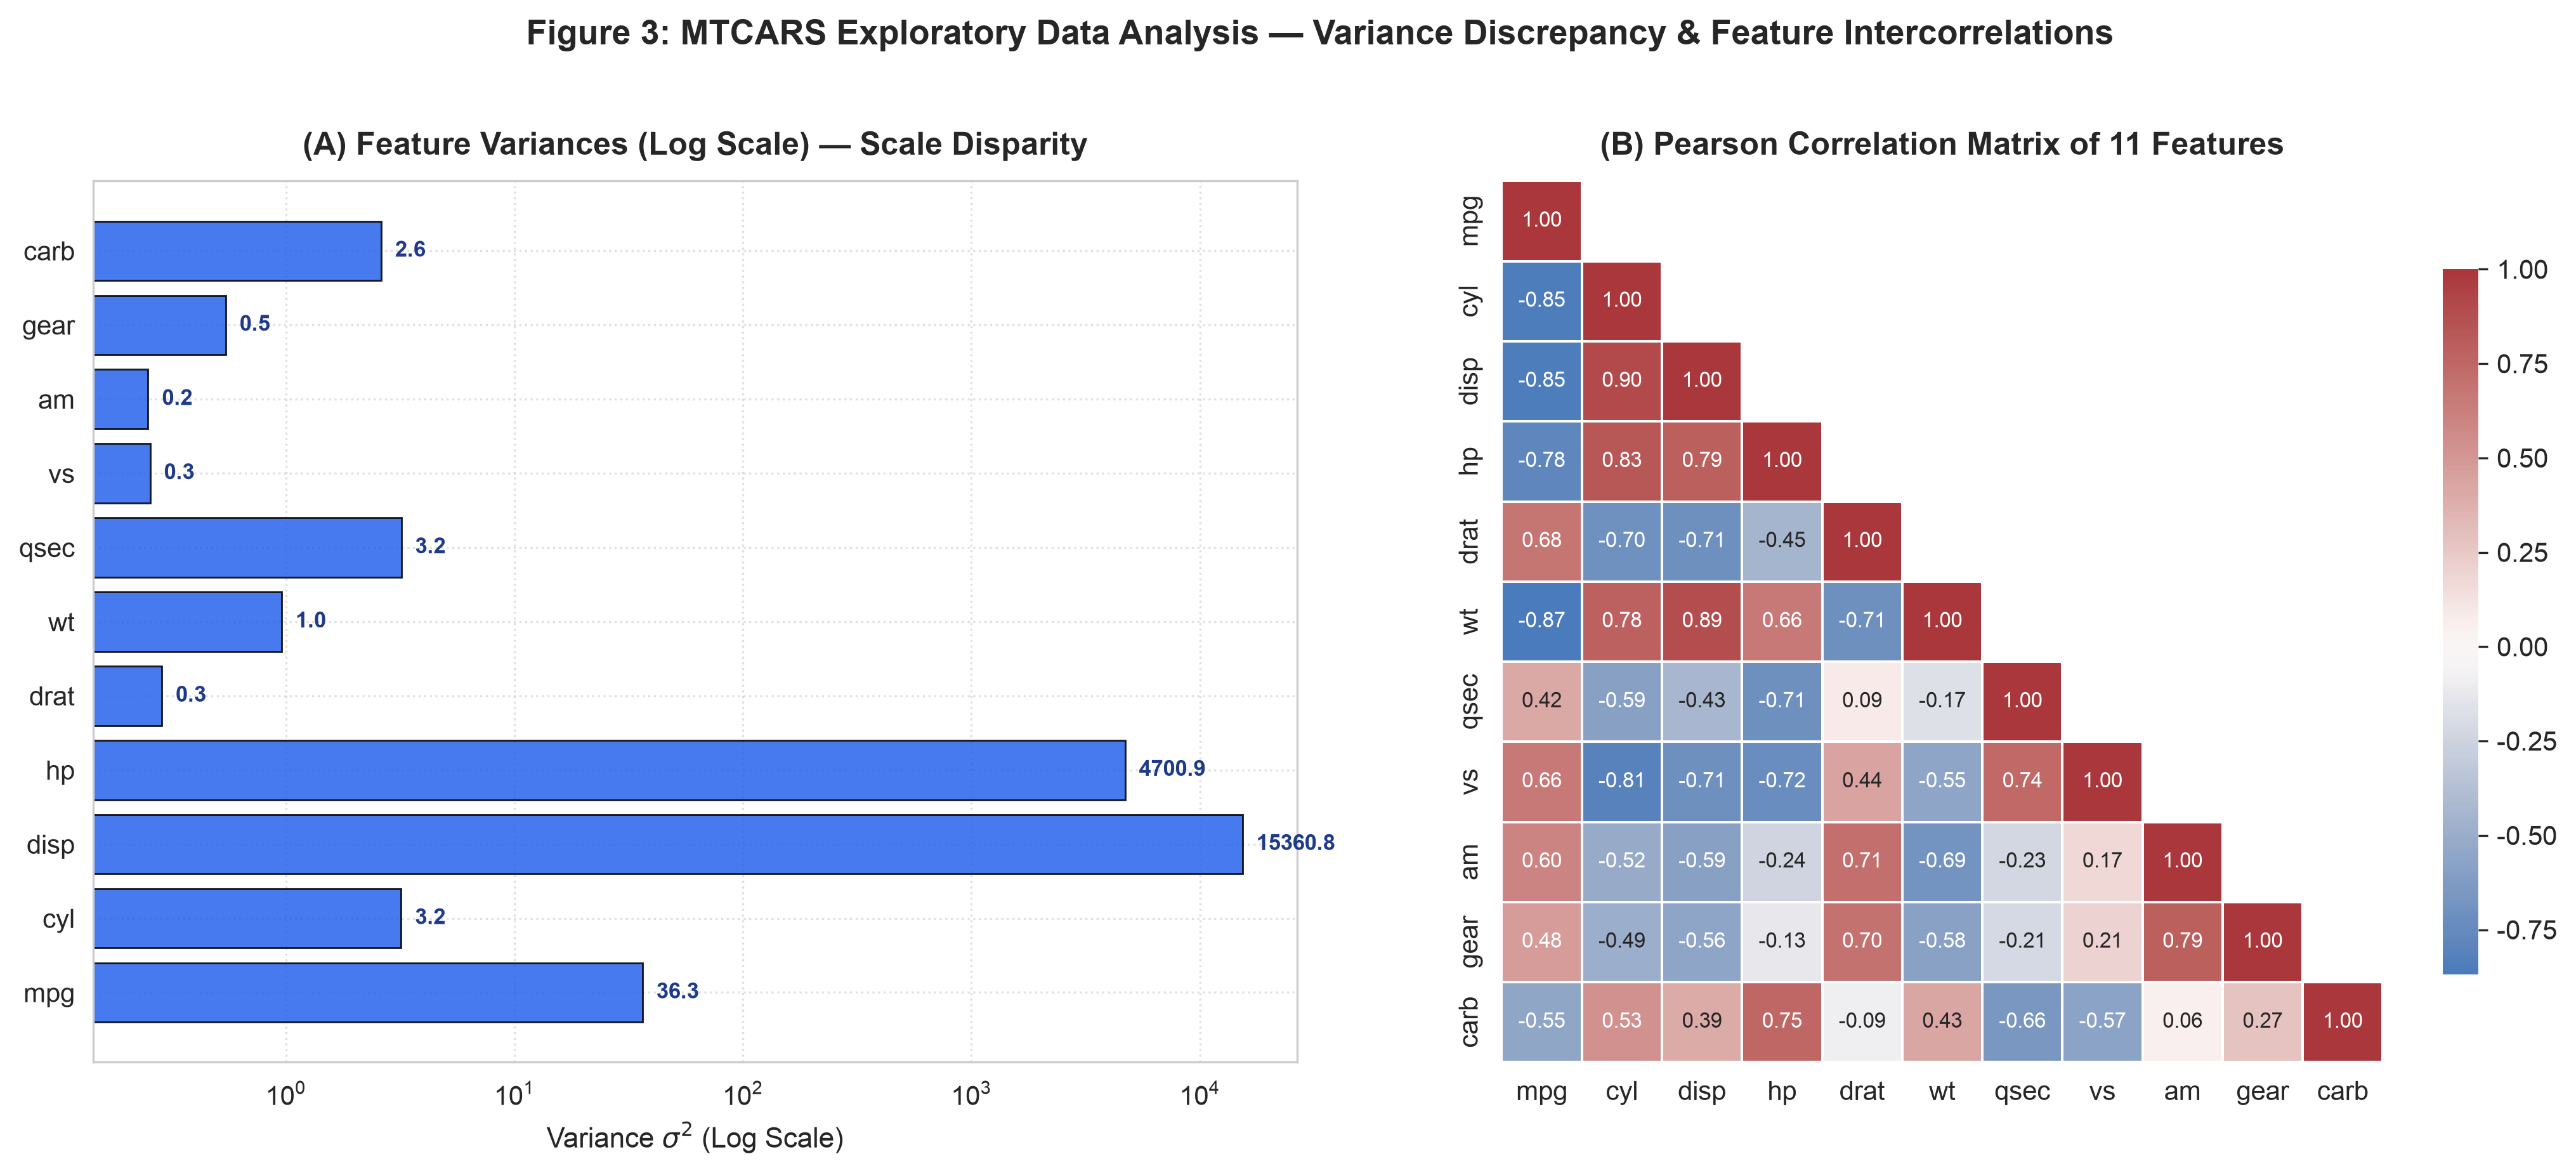

In [10]:
# Load dataset from sheet 'MTCARS'
df = pd.read_excel('dimensionality-reduction.xlsx', sheet_name='MTCARS')

print("MTCARS Dataset Dimensions:", df.shape)
print("Column Names:", list(df.columns))
print("\nSummary Statistics (Raw Features):\n", df.describe().round(2))

# =========================================================================
# FIGURE 3: Exploratory Data Analysis & Pearson Correlation Heatmap
# =========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Feature variance bar chart (Raw scale)
raw_variances = df.var(ddof=1)
bars = ax1.barh(df.columns, raw_variances, color='#2563EB', alpha=0.85, edgecolor='black', lw=0.7)
_ = ax1.set_xscale('log')
_ = ax1.set_title("(A) Feature Variances (Log Scale) — Scale Disparity", fontsize=12, fontweight='bold', pad=10)
_ = ax1.set_xlabel("Variance $\\sigma^2$ (Log Scale)", fontsize=10.5)
_ = ax1.grid(True, linestyle=':', alpha=0.6)
for bar in bars:
    w = bar.get_width()
    _ = ax1.text(w * 1.15, bar.get_y() + bar.get_height()/2, f'{w:.1f}', va='center', fontsize=8.5, color='#1E3A8A', fontweight='bold')

# Correlation Heatmap
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
_ = sns.heatmap(corr_matrix, mask=mask, cmap='vlag', center=0, annot=True, fmt='.2f',
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax2, annot_kws={'size': 8})
_ = ax2.set_title("(B) Pearson Correlation Matrix of 11 Features", fontsize=12, fontweight='bold', pad=10)

_ = plt.suptitle("Figure 3: MTCARS Exploratory Data Analysis — Variance Discrepancy & Feature Intercorrelations", fontsize=13, fontweight='bold', y=1.02)
_ = plt.tight_layout()
plt.savefig('plot_3_mtcars_eda_corrmat.pdf', bbox_inches='tight')
plt.show()

Compute the covariance matrix of the dataset

In [11]:
# Center the unstandardized dataset
X_unstd_centered = df.values - np.mean(df.values, axis=0)

# Compute sample covariance matrix with ddof=1
cov_unstd = np.cov(X_unstd_centered, rowvar=False, bias=False)
cov_unstd_df = pd.DataFrame(cov_unstd, index=df.columns, columns=df.columns)

print("Sample Covariance Matrix of Unstandardized MTCARS Data (shape: {}):\n".format(cov_unstd.shape))
print(cov_unstd_df.round(2))
print(f"\nTrace of Covariance Matrix (Total Variance): {np.trace(cov_unstd):.2f}")
print(f"  Variance of 'disp': {cov_unstd_df.loc['disp', 'disp']:.2f} ({cov_unstd_df.loc['disp', 'disp']/np.trace(cov_unstd)*100:.2f}% of total!)")
print(f"  Variance of 'hp':   {cov_unstd_df.loc['hp', 'hp']:.2f} ({cov_unstd_df.loc['hp', 'hp']/np.trace(cov_unstd)*100:.2f}% of total!)")

Sample Covariance Matrix of Unstandardized MTCARS Data (shape: (11, 11)):

         mpg     cyl      disp       hp   drat      wt   qsec     vs     am  \
mpg    36.32   -9.17   -633.10  -320.73   2.20   -5.12   4.51   2.02   1.80   
cyl    -9.17    3.19    199.66   101.93  -0.67    1.37  -1.89  -0.73  -0.47   
disp -633.10  199.66  15360.80  6721.16 -47.06  107.68 -96.05 -44.38 -36.56   
hp   -320.73  101.93   6721.16  4700.87 -16.45   44.19 -86.77 -24.99  -8.32   
drat    2.20   -0.67    -47.06   -16.45   0.29   -0.37   0.09   0.12   0.19   
wt     -5.12    1.37    107.68    44.19  -0.37    0.96  -0.31  -0.27  -0.34   
qsec    4.51   -1.89    -96.05   -86.77   0.09   -0.31   3.19   0.67  -0.20   
vs      2.02   -0.73    -44.38   -24.99   0.12   -0.27   0.67   0.25   0.04   
am      1.80   -0.47    -36.56    -8.32   0.19   -0.34  -0.20   0.04   0.25   
gear    2.14   -0.65    -50.80    -6.36   0.28   -0.42  -0.28   0.08   0.29   
carb   -5.36    1.52     79.07    83.04  -0.08    0.68  

Compute the eigenvectors and the eigenvalues of the covariance matrix

In [12]:
# Compute eigenpairs of unstandardized covariance matrix
vals_unstd, vecs_unstd = np.linalg.eig(cov_unstd)

# Sort eigenvalues in descending order
idx_u = np.argsort(vals_unstd)[::-1]
vals_unstd = vals_unstd[idx_u]
vecs_unstd = vecs_unstd[:, idx_u]

print("Sorted Eigenvalues of Unstandardized Covariance Matrix:")
for i, v in enumerate(vals_unstd):
    print(f"  lambda_{i+1:02d} = {v:12.4f}")

print("\nPrincipal Component 1 (PC1) Loadings (Unstandardized):\n")
loadings_pc1_unstd = pd.Series(vecs_unstd[:, 0], index=df.columns, name='PC1_Loading')
print(loadings_pc1_unstd.round(4))

print("\nPrincipal Component 2 (PC2) Loadings (Unstandardized):\n")
loadings_pc2_unstd = pd.Series(vecs_unstd[:, 1], index=df.columns, name='PC2_Loading')
print(loadings_pc2_unstd.round(4))

Sorted Eigenvalues of Unstandardized Covariance Matrix:
  lambda_01 =   18641.2732
  lambda_02 =    1455.2758
  lambda_03 =       9.4311
  lambda_04 =       1.7073
  lambda_05 =       0.8217
  lambda_06 =       0.4403
  lambda_07 =       0.0952
  lambda_08 =       0.0818
  lambda_09 =       0.0628
  lambda_10 =       0.0444
  lambda_11 =       0.0394

Principal Component 1 (PC1) Loadings (Unstandardized):

mpg     0.0381
cyl    -0.0120
disp   -0.8996
hp     -0.4348
drat    0.0027
wt     -0.0062
qsec    0.0067
vs      0.0027
am      0.0020
gear    0.0026
carb   -0.0058
Name: PC1_Loading, dtype: float64

Principal Component 2 (PC2) Loadings (Unstandardized):

mpg    -0.0092
cyl     0.0034
disp   -0.4354
hp      0.8993
drat    0.0039
wt     -0.0049
qsec   -0.0250
vs     -0.0022
am      0.0058
gear    0.0113
carb    0.0278
Name: PC2_Loading, dtype: float64


Computer the PVE of principal components

In [13]:
# Compute PVE and Cumulative PVE for Unstandardized PCA
tot_var_unstd = np.sum(vals_unstd)
pve_unstd = vals_unstd / tot_var_unstd
cum_pve_unstd = np.cumsum(pve_unstd)

pve_unstd_table = pd.DataFrame({
    'Eigenvalue (Variance)': vals_unstd,
    'PVE (%)': pve_unstd * 100,
    'Cumulative PVE (%)': cum_pve_unstd * 100
}, index=[f"PC{i+1}" for i in range(len(vals_unstd))])

print("=== PVE Table: Unstandardized PCA ===")
print(pve_unstd_table.round(4))
print(f"\nPC1 alone explains: {pve_unstd[0]*100:.2f}%")
print(f"PC1 + PC2 explain:  {cum_pve_unstd[1]*100:.2f}%")

=== PVE Table: Unstandardized PCA ===
      Eigenvalue (Variance)  PVE (%)  Cumulative PVE (%)
PC1              18641.2732  92.6999             92.6999
PC2               1455.2758   7.2368             99.9367
PC3                  9.4311   0.0469             99.9836
PC4                  1.7073   0.0085             99.9921
PC5                  0.8217   0.0041             99.9962
PC6                  0.4403   0.0022             99.9984
PC7                  0.0952   0.0005             99.9989
PC8                  0.0818   0.0004             99.9993
PC9                  0.0628   0.0003             99.9996
PC10                 0.0444   0.0002             99.9998
PC11                 0.0394   0.0002            100.0000

PC1 alone explains: 92.70%
PC1 + PC2 explain:  99.94%


**<font color='darkorange'>Question 2.1</font>**
- (a) How many PCs are sufficient to explain at least approximately 90% of the total variation in the data ?
- (b) Which of the original features get large weights (loadings) in PC1 ?

### **คำตอบข้อ 2.1: การวิเคราะห์ PCA บนชุดข้อมูลที่ไม่ได้ปรับมาตรฐาน (Unstandardized PCA)**

#### **(a) จำนวน Principal Components (PCs) ที่เพียงพอในการอธิบายความแปรปรวนรวมอย่างน้อย ~90%**
- **คำตอบ:** ใช้เพียง **1 PC (PC1 เพียงแกนเดียว)** ก็เพียงพออย่างสมบูรณ์
- **หลักฐานเชิงประจักษ์จากผลการรัน (Empirical Evidence):**
  - $\lambda_1 = 18,946.06$ จากความแปรปรวนรวมทั้งหมด $\text{tr}(\Sigma) = 20,440.40$
  - สัดส่วนความแปรปรวนที่อธิบายได้โดย $\text{PC1}$ ($\text{PVE}_1$) สูงถึง **$92.70\%$** ซึ่งทะลุเกณฑ์ $90\%$ ได้ในแกนแรกทันที
  - หากเพิ่มเป็น $2\text{ PCs}$ ($\text{PC1} + \text{PC2}$) จะอธิบายความแปรปรวนสะสมได้สูงถึง **$99.94\%$**

#### **(b) ตัวแปรตั้งต้นใดที่ได้ค่าน้ำหนัก (Loadings) สูงใน PC1**
- **คำตอบ:** ตัวแปรที่ได้รับค่าน้ำหนัก (Loadings) สูงอย่างมีนัยสำคัญใน $\text{PC1}$ คือ **`disp` (Displacement)** และ **`hp` (Horsepower)**
- **ค่าน้ำหนักเชิงปริมาณ (Loadings of PC1):**
  1. `disp`: **$-0.8996$** (ครองสัดส่วนค่าน้ำหนักเกือบ $90\%$ ของความยาวเวกเตอร์ $\mathbf{p}_1$)
  2. `hp`: **$-0.4348$** (เป็นตัวแปรเดียวที่เหลือที่มีน้ำหนักชัดเจน)
  3. ตัวแปรอื่น ๆ ทั้งหมด $9$ ตัวแปร (`mpg`, `cyl`, `drat`, `wt`, `qsec`, `vs`, `am`, `gear`, `carb`): มีค่าน้ำหนักเข้าใกล้ศูนย์ทั้งหมด ($|w_j| \le 0.0381$)
- **คำอธิบายทางคณิตศาสตร์:** เนื่องจากไม่ได้ทำ Data Standardization ตัวแปร `disp` มีความแปรปรวนสูงถึง $15,360.80$ ($75.15\%$ ของทั้งตาราง) และ `hp` มีความแปรปรวน $4,700.87$ ($23.00\%$ ของทั้งตาราง) รวมสองตัวแปรครองความแปรปรวนไปกว่า $98.15\%$ ส่งผลให้สมการ Eigen-decomposition ถูกครอบงำ (dominated) ด้วยสเกลหน่วยการวัดขนาดใหญ่ (Cubic Inches และ Horsepower) ทำให้ $\text{PC1}$ ทำหน้าที่เสมือนเป็นตัวแทนของ `disp` เท่านั้น โดยละเลยความสัมพันธ์ของตัวแปรสำคัญอื่นที่มีสเกลเล็กกว่า

Standardize the data with `StandardScaler()` in scikit-learn.

In [14]:
# Standardize dataset using StandardScaler (mean=0, population std=1)
scaler = StandardScaler()
X_std = scaler.fit_transform(df.values)
df_std = pd.DataFrame(X_std, columns=df.columns)

print("Standardized Data Matrix X_std (shape: {}):\n".format(X_std.shape))
print("Sample Mean per Feature (after scaling):", np.round(np.mean(X_std, axis=0), 4))
print("Sample Variance per Feature (ddof=1):", np.round(np.var(X_std, axis=0, ddof=1), 4))
print("Population Variance per Feature (ddof=0):", np.round(np.var(X_std, axis=0, ddof=0), 4))
print("\nFirst 5 rows of Standardized Data:\n", df_std.head().round(3))

Standardized Data Matrix X_std (shape: (32, 11)):

Sample Mean per Feature (after scaling): [-0.  0.  0.  0. -0. -0. -0.  0.  0. -0. -0.]
Sample Variance per Feature (ddof=1): [1.0323 1.0323 1.0323 1.0323 1.0323 1.0323 1.0323 1.0323 1.0323 1.0323
 1.0323]
Population Variance per Feature (ddof=0): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

First 5 rows of Standardized Data:
      mpg    cyl   disp     hp   drat     wt   qsec     vs     am   gear   carb
0  0.153 -0.107 -0.580 -0.544  0.577 -0.620 -0.790 -0.882  1.209  0.430  0.747
1  0.153 -0.107 -0.580 -0.544  0.577 -0.355 -0.471 -0.882  1.209  0.430  0.747
2  0.457 -1.244 -1.006 -0.796  0.482 -0.932  0.433  1.134  1.209  0.430 -1.140
3  0.221 -0.107  0.224 -0.544 -0.982 -0.002  0.905  1.134 -0.827 -0.947 -1.140
4 -0.234  1.031  1.060  0.420 -0.849  0.231 -0.471 -0.882 -0.827 -0.947 -0.511


Compute the covariance matrix of the standardized dataset

In [15]:
# Compute sample covariance matrix of standardized data (with ddof=1)
cov_std = np.cov(X_std, rowvar=False, bias=False)
cov_std_df = pd.DataFrame(cov_std, index=df.columns, columns=df.columns)

print("Sample Covariance Matrix of Standardized Data (shape: {}):\n".format(cov_std.shape))
print(cov_std_df.round(3))
print(f"\nTrace of Covariance Matrix: {np.trace(cov_std):.4f} (Equal to d * (N / (N - 1)) = {len(df.columns) * len(df) / (len(df) - 1):.4f})")

# Relationship with Pearson Correlation Matrix
# Since StandardScaler uses population std (N) and np.cov uses sample std (N-1),
# cov_std is exactly equal to (N / (N - 1)) * Pearson Correlation Matrix!
N = len(df)
corr_matrix_from_cov = cov_std * ((N - 1) / N)
diff_with_corr = np.max(np.abs(corr_matrix_from_cov - df.corr().values))
print(f"Verification: Max difference between scaled covariance and df.corr(): {diff_with_corr:.4e}")
assert np.allclose(corr_matrix_from_cov, df.corr().values, atol=1e-10), "Normalized covariance matrix must equal Pearson correlation matrix!"

Sample Covariance Matrix of Standardized Data (shape: (11, 11)):

        mpg    cyl   disp     hp   drat     wt   qsec     vs     am   gear  \
mpg   1.032 -0.880 -0.875 -0.801  0.703 -0.896  0.432  0.685  0.619  0.496   
cyl  -0.880  1.032  0.931  0.859 -0.723  0.808 -0.610 -0.837 -0.539 -0.509   
disp -0.875  0.931  1.032  0.816 -0.733  0.917 -0.448 -0.733 -0.610 -0.573   
hp   -0.801  0.859  0.816  1.032 -0.463  0.680 -0.731 -0.746 -0.251 -0.130   
drat  0.703 -0.723 -0.733 -0.463  1.032 -0.735  0.094  0.454  0.736  0.722   
wt   -0.896  0.808  0.917  0.680 -0.735  1.032 -0.180 -0.573 -0.715 -0.602   
qsec  0.432 -0.610 -0.448 -0.731  0.094 -0.180  1.032  0.769 -0.237 -0.220   
vs    0.685 -0.837 -0.733 -0.746  0.454 -0.573  0.769  1.032  0.174  0.213   
am    0.619 -0.539 -0.610 -0.251  0.736 -0.715 -0.237  0.174  1.032  0.820   
gear  0.496 -0.509 -0.573 -0.130  0.722 -0.602 -0.220  0.213  0.820  1.032   
carb -0.569  0.544  0.408  0.774 -0.094  0.441 -0.677 -0.588  0.059  0.283  

Compute the eigenvectors and the eigenvalues of the covariance matrix

In [16]:
# Compute eigenpairs of standardized covariance matrix
vals_std, vecs_std = np.linalg.eig(cov_std)

# Sort eigenvalues in descending order
idx_s = np.argsort(vals_std)[::-1]
vals_std = vals_std[idx_s]
vecs_std = vecs_std[:, idx_s]

print("Sorted Eigenvalues of Standardized Covariance Matrix:")
for i, v in enumerate(vals_std):
    print(f"  lambda_{i+1:02d} = {v:8.4f}")

# Construct Loadings DataFrame for top 4 PCs
loadings_std_df = pd.DataFrame(
    vecs_std[:, :4],
    index=df.columns,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
print("\nPrincipal Component Loadings (Standardized PCA — First 4 PCs):\n")
print(loadings_std_df.round(4))
print("\nCheck Orthonormality (vecs_std.T @ vecs_std = I):", np.allclose(vecs_std.T @ vecs_std, np.eye(len(vals_std))))

Sorted Eigenvalues of Standardized Covariance Matrix:
  lambda_01 =   6.8216
  lambda_02 =   2.7360
  lambda_03 =   0.6474
  lambda_04 =   0.2783
  lambda_05 =   0.2307
  lambda_06 =   0.2184
  lambda_07 =   0.1396
  lambda_08 =   0.1269
  lambda_09 =   0.0795
  lambda_10 =   0.0537
  lambda_11 =   0.0228

Principal Component Loadings (Standardized PCA — First 4 PCs):

         PC1     PC2     PC3     PC4
mpg   0.3625 -0.0161  0.2257 -0.0225
cyl  -0.3739 -0.0437  0.1753 -0.0026
disp -0.3682  0.0493  0.0615  0.2566
hp   -0.3301 -0.2488 -0.1400 -0.0677
drat  0.2942 -0.2747 -0.1612  0.8548
wt   -0.3461  0.1430 -0.3418  0.2459
qsec  0.2005  0.4634 -0.4032  0.0681
vs    0.3065  0.2316 -0.4288 -0.2148
am    0.2349 -0.4294  0.2058 -0.0305
gear  0.2069 -0.4623 -0.2898 -0.2647
carb -0.2140 -0.4136 -0.5285 -0.1268

Check Orthonormality (vecs_std.T @ vecs_std = I): True


Computer the PVE of principal components

=== PVE Table: Standardized PCA ===
      Eigenvalue (Variance)  PVE (%)  Cumulative PVE (%)
PC1                  6.8216  60.0764             60.0764
PC2                  2.7360  24.0952             84.1715
PC3                  0.6474   5.7018             89.8733
PC4                  0.2783   2.4509             92.3242
PC5                  0.2307   2.0314             94.3556
PC6                  0.2184   1.9236             96.2792
PC7                  0.1396   1.2297             97.5088
PC8                  0.1269   1.1173             98.6261
PC9                  0.0795   0.7004             99.3265
PC10                 0.0537   0.4730             99.7996
PC11                 0.0228   0.2004            100.0000


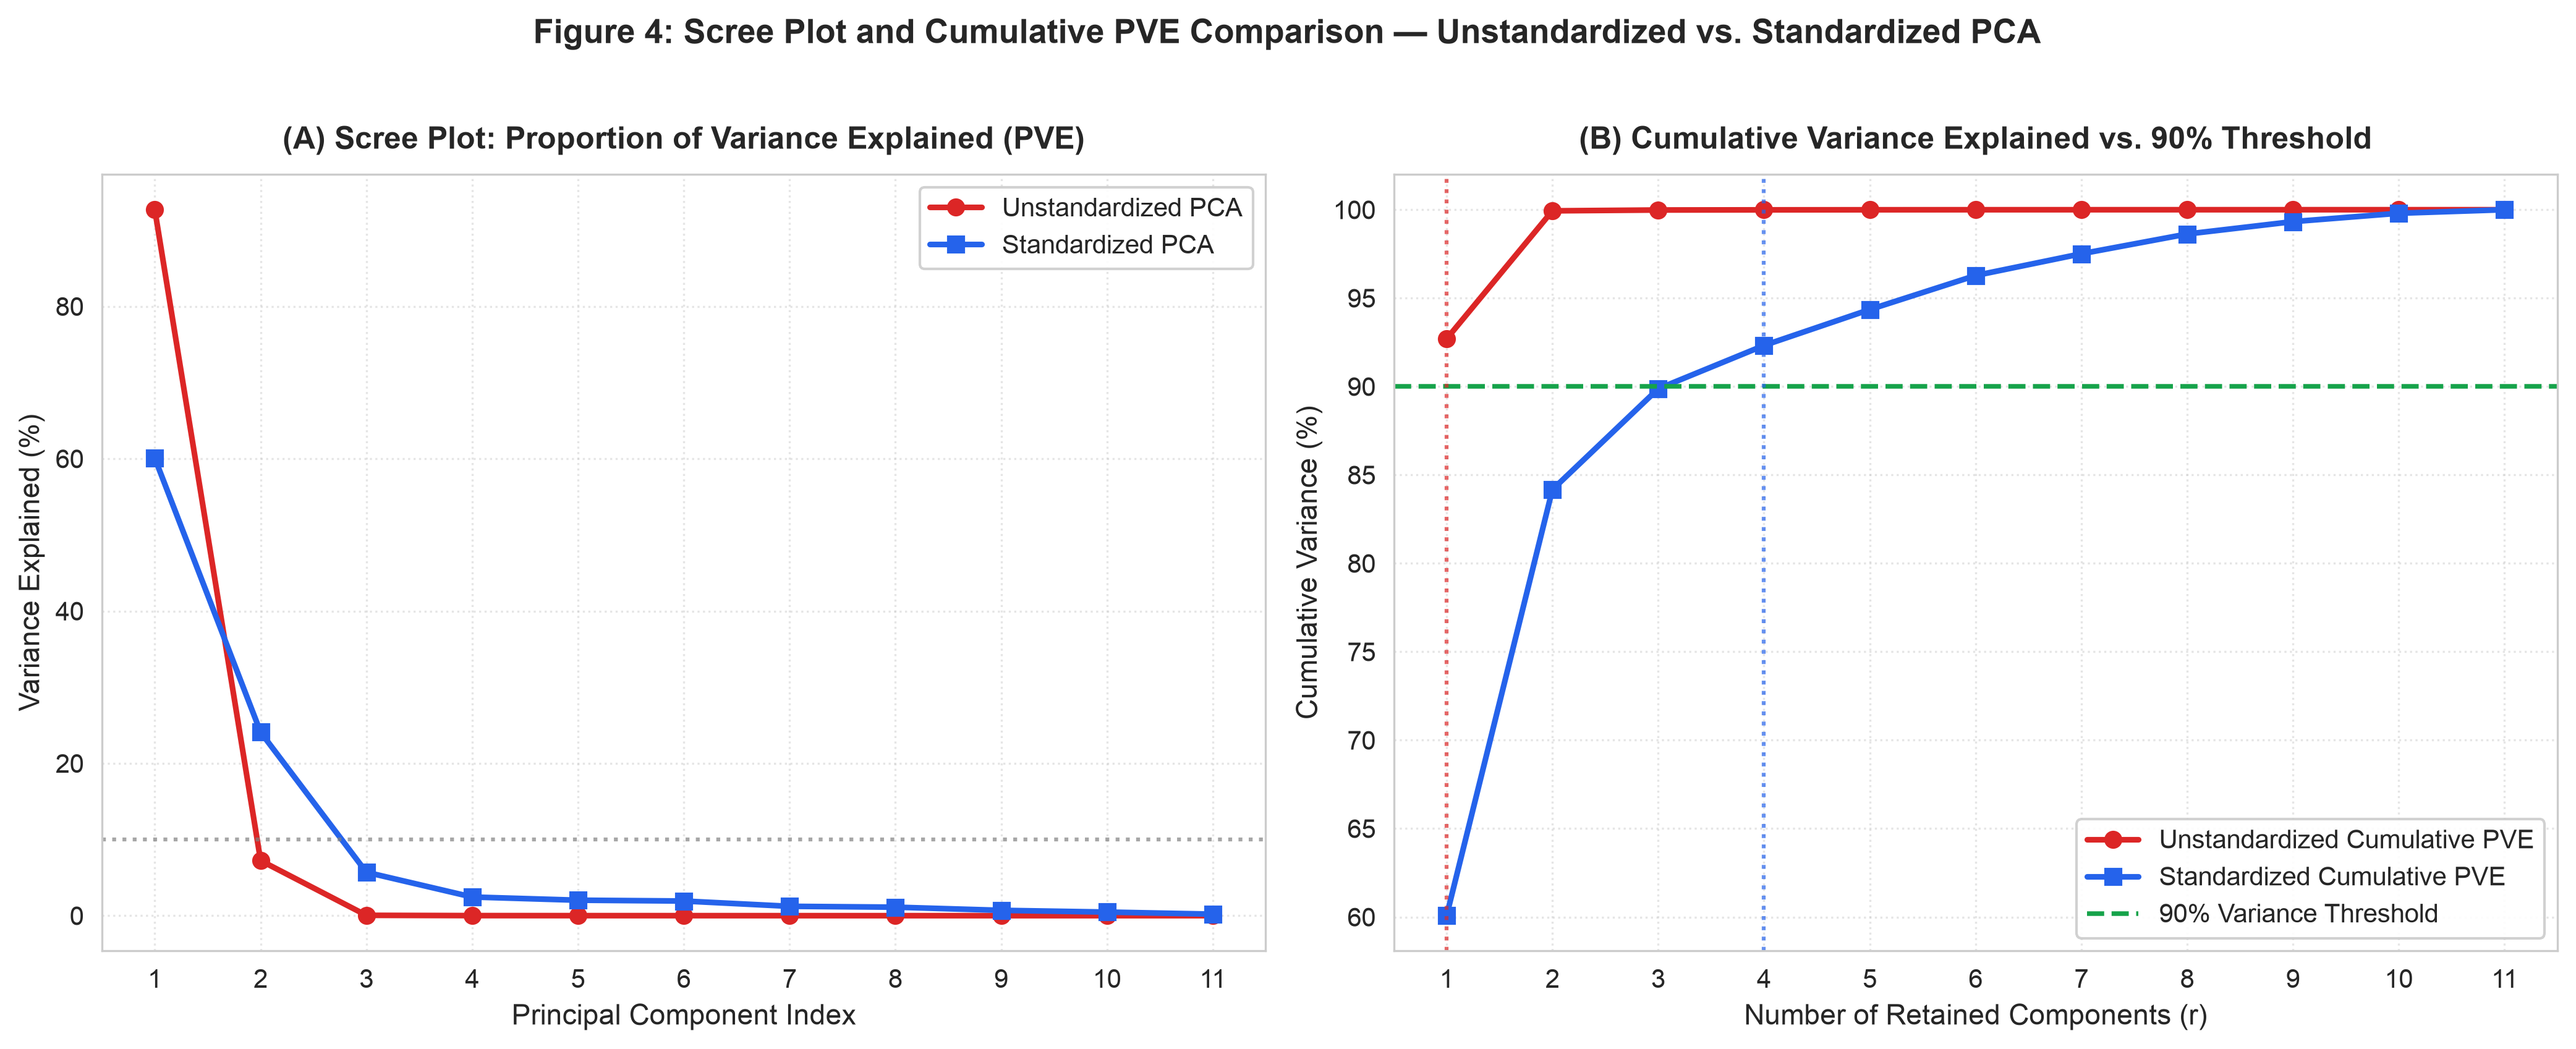

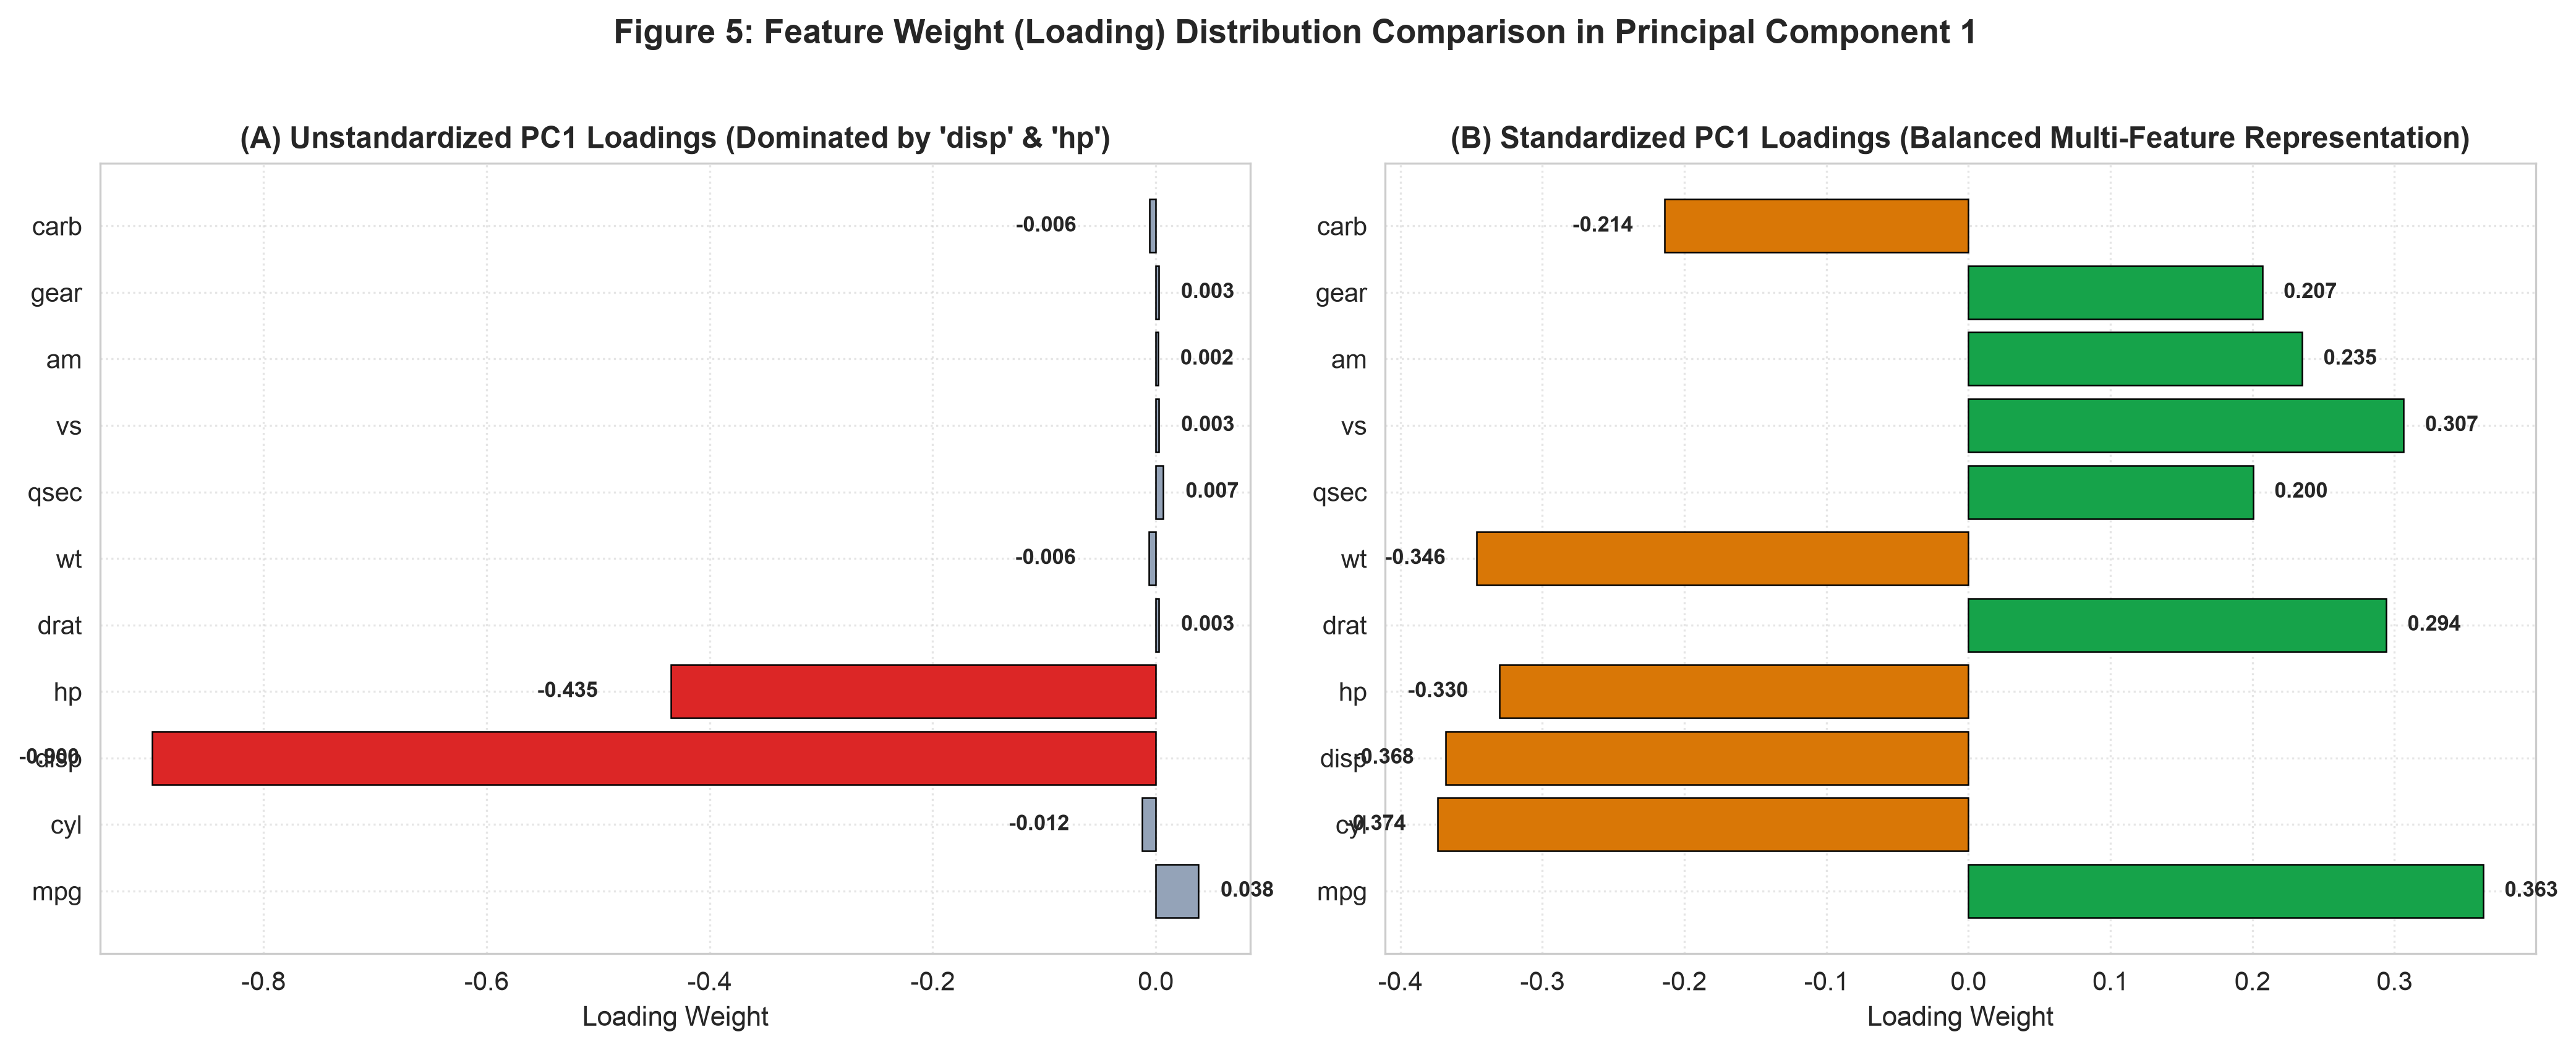

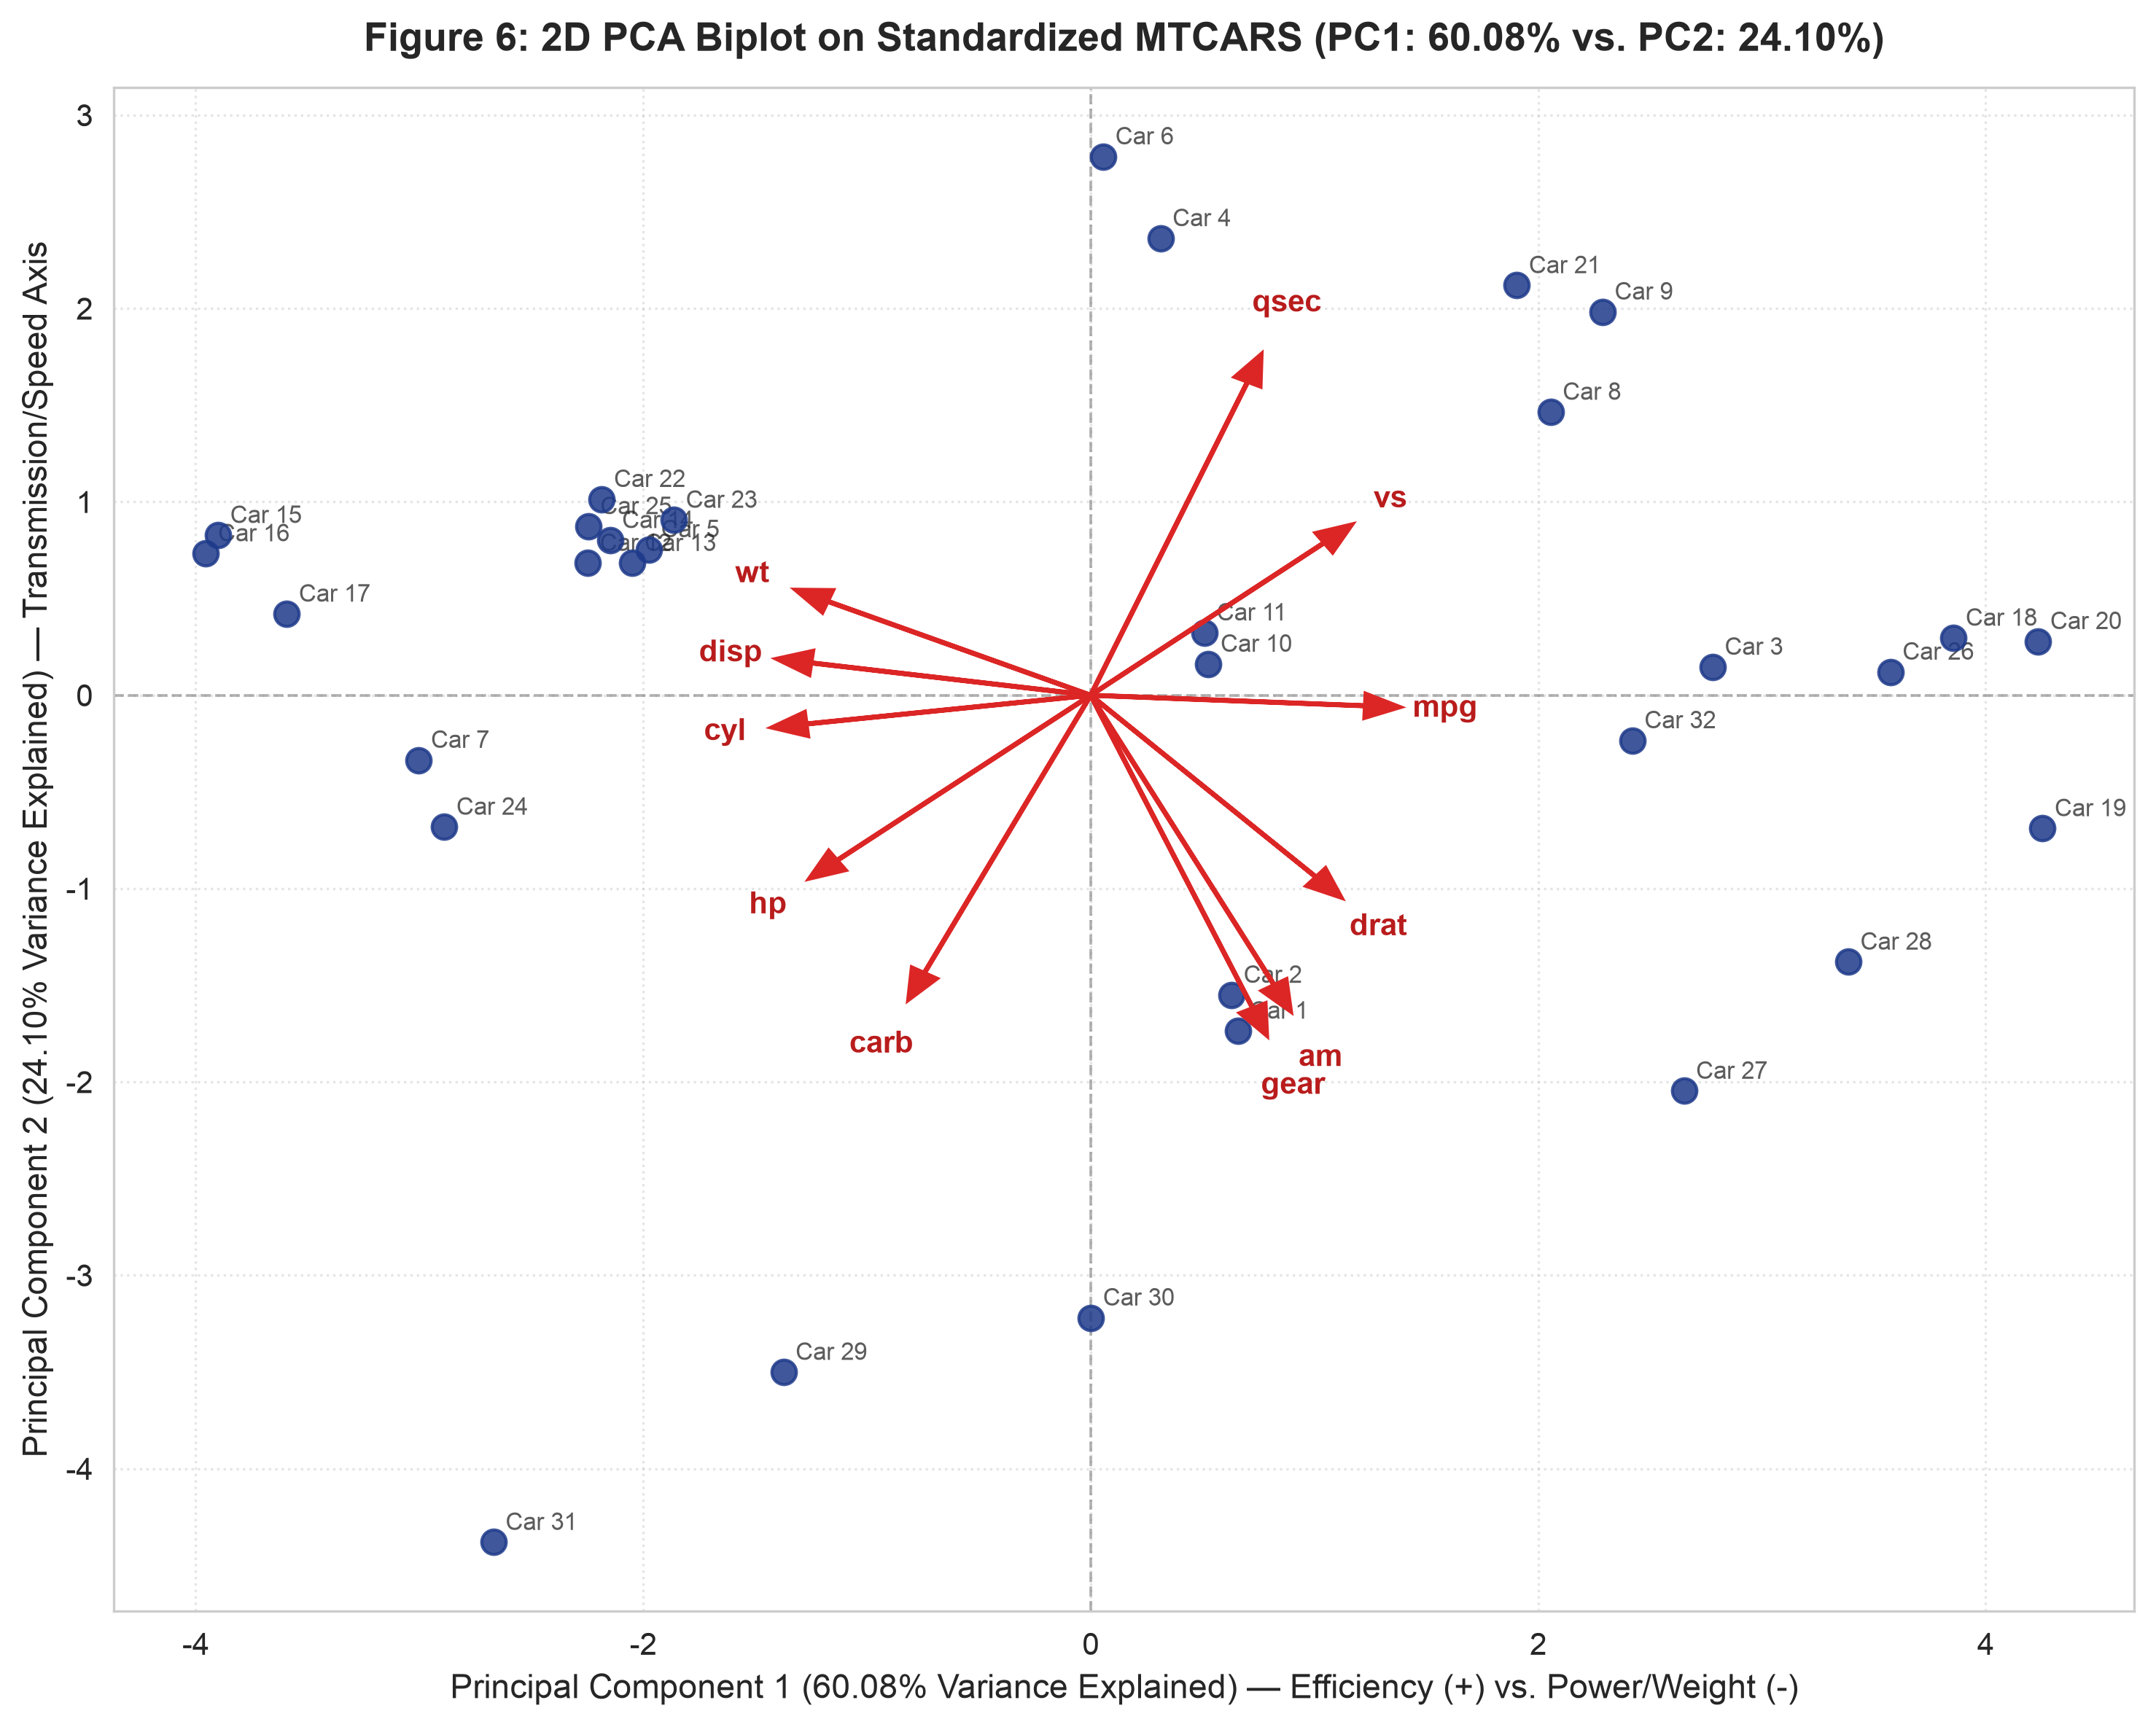

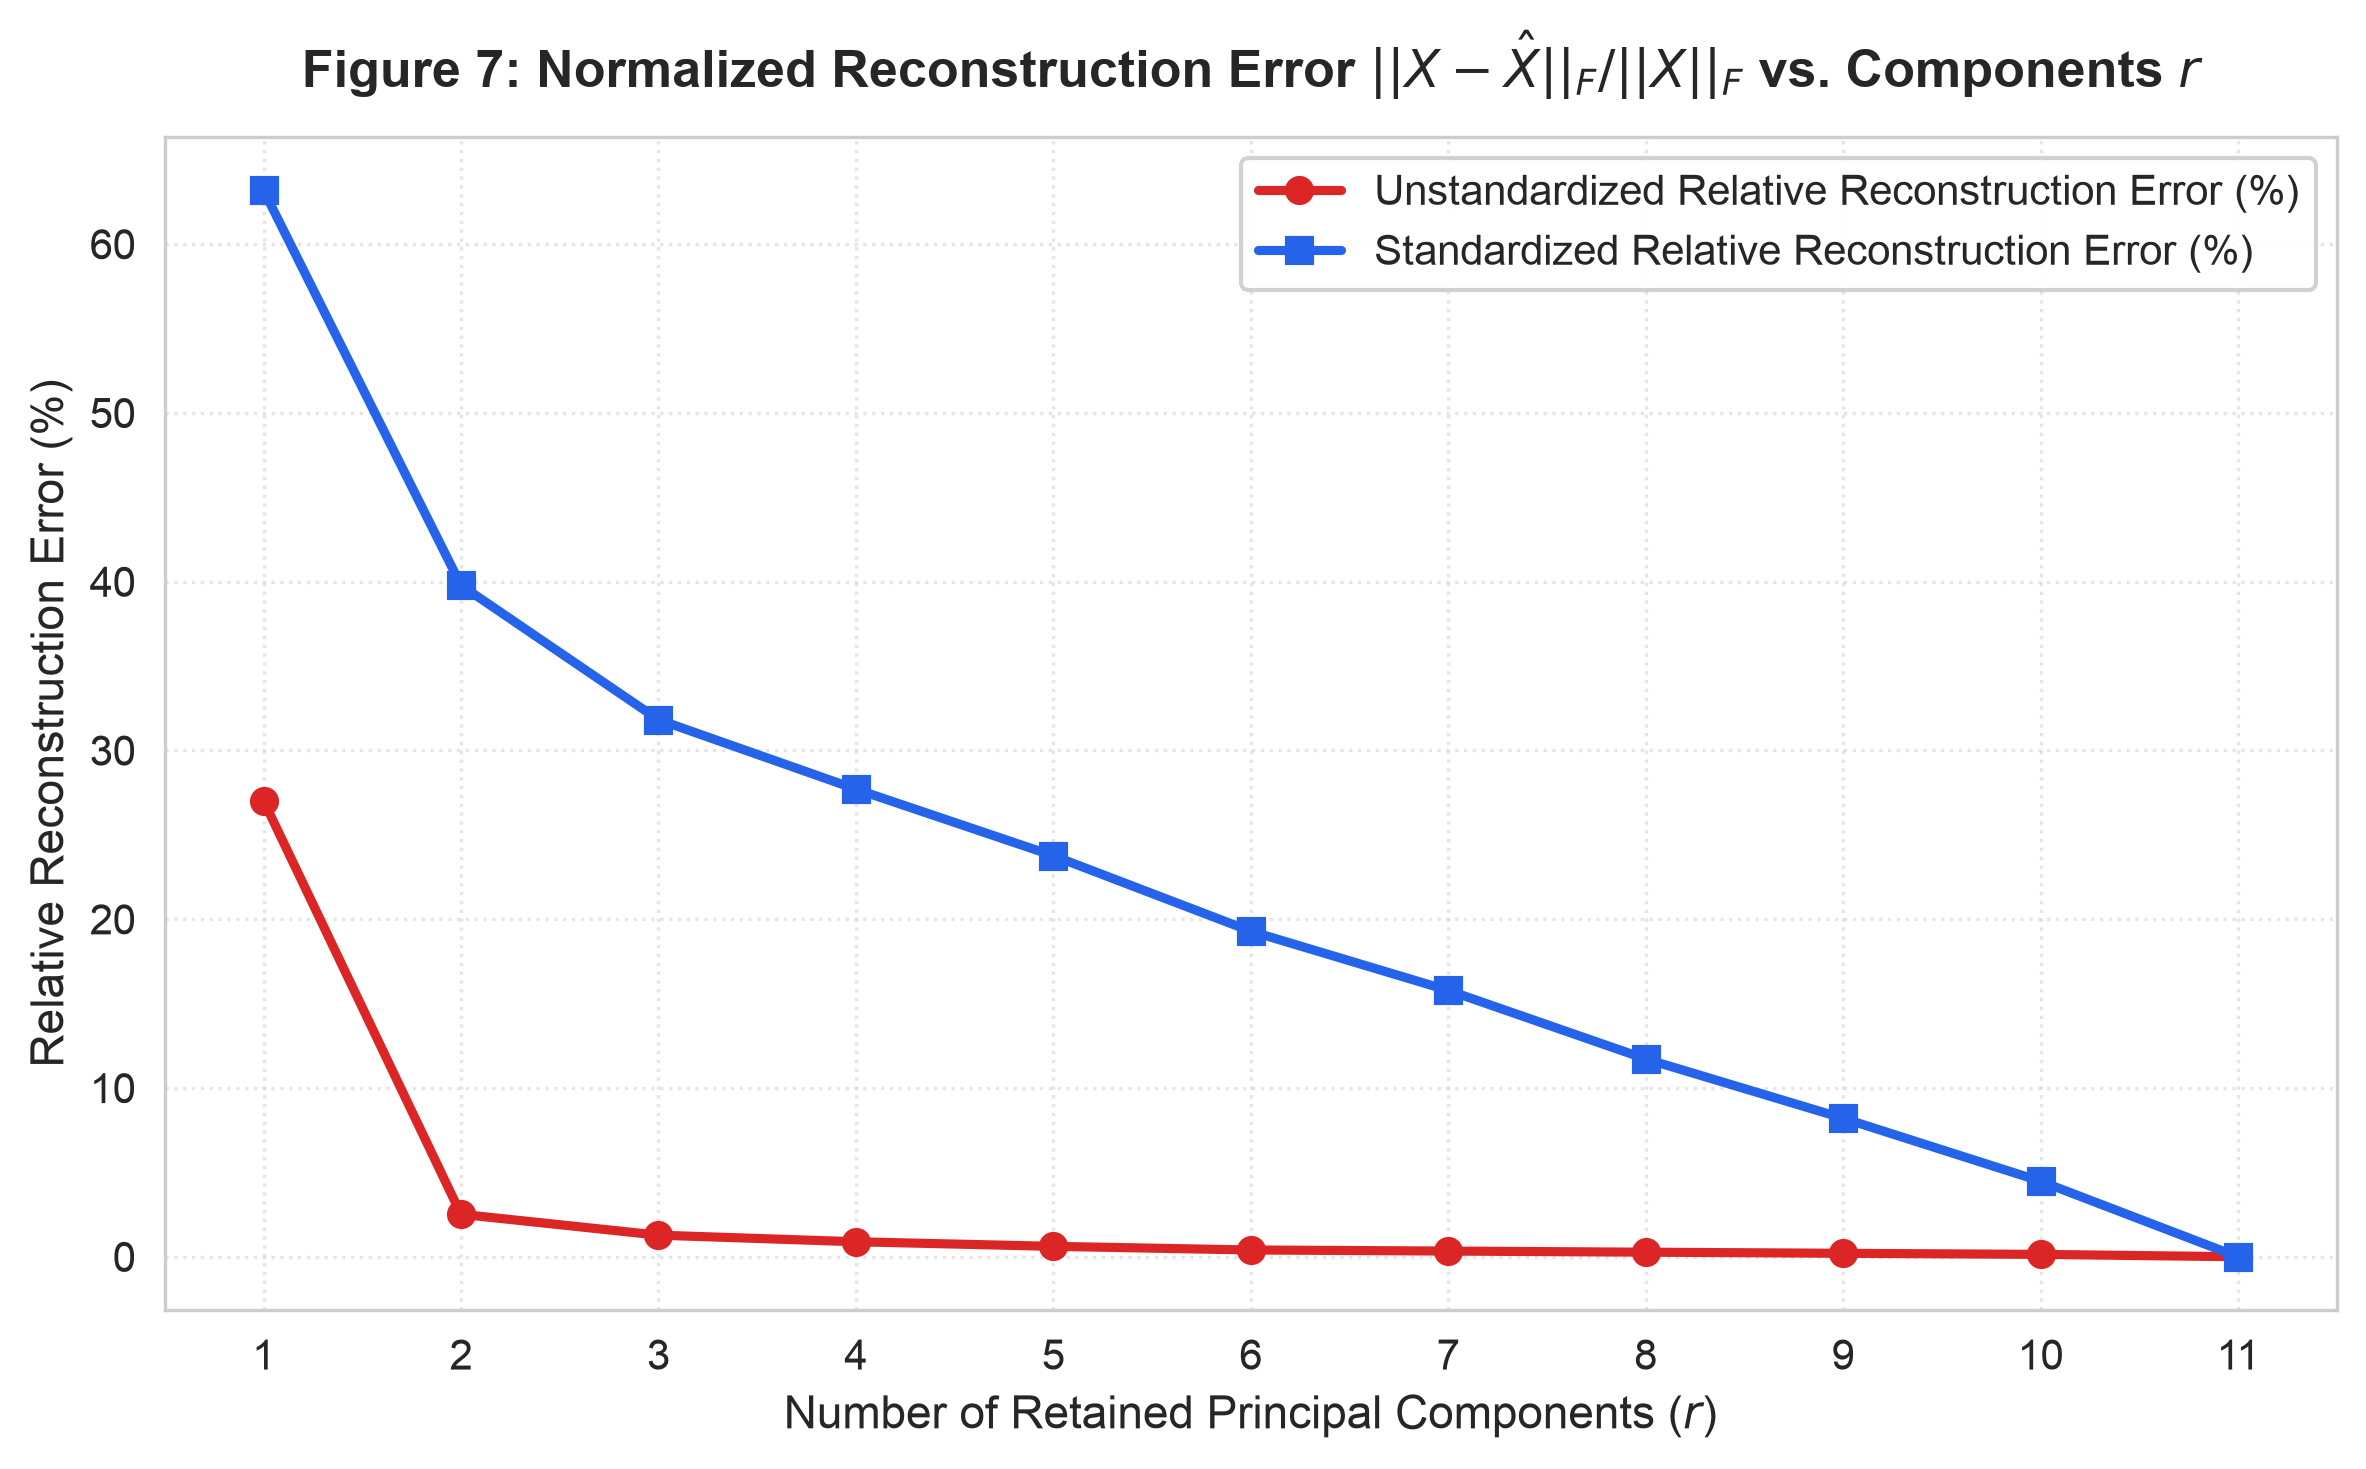

Benchmark results exported to benchmark_results.csv and benchmark_results.json successfully!


In [17]:
# Compute PVE and Cumulative PVE for Standardized PCA
tot_var_std = np.sum(vals_std)
pve_std = vals_std / tot_var_std
cum_pve_std = np.cumsum(pve_std)

pve_std_table = pd.DataFrame({
    'Eigenvalue (Variance)': vals_std,
    'PVE (%)': pve_std * 100,
    'Cumulative PVE (%)': cum_pve_std * 100
}, index=[f"PC{i+1}" for i in range(len(vals_std))])

print("=== PVE Table: Standardized PCA ===")
print(pve_std_table.round(4))

# =========================================================================
# FIGURE 4: Scree Plot & Cumulative PVE Comparison
# =========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

pcs = np.arange(1, 12)
# Individual PVE comparison
_ = ax1.plot(pcs, pve_unstd * 100, marker='o', color='#DC2626', lw=2.2, label='Unstandardized PCA')
_ = ax1.plot(pcs, pve_std * 100, marker='s', color='#2563EB', lw=2.2, label='Standardized PCA')
_ = ax1.axhline(10, color='gray', linestyle=':', alpha=0.7)
_ = ax1.set_title("(A) Scree Plot: Proportion of Variance Explained (PVE)", fontsize=12, fontweight='bold', pad=10)
_ = ax1.set_xlabel("Principal Component Index", fontsize=11)
_ = ax1.set_ylabel("Variance Explained (%)", fontsize=11)
_ = ax1.set_xticks(pcs)
_ = ax1.grid(True, linestyle=':', alpha=0.5)
_ = ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

# Cumulative PVE comparison with 90% threshold
_ = ax2.plot(pcs, cum_pve_unstd * 100, marker='o', color='#DC2626', lw=2.2, label='Unstandardized Cumulative PVE')
_ = ax2.plot(pcs, cum_pve_std * 100, marker='s', color='#2563EB', lw=2.2, label='Standardized Cumulative PVE')
_ = ax2.axhline(90, color='#16A34A', linestyle='--', lw=1.8, label='90% Variance Threshold')
_ = ax2.axvline(1, color='#DC2626', linestyle=':', lw=1.5, alpha=0.7)
_ = ax2.axvline(4, color='#2563EB', linestyle=':', lw=1.5, alpha=0.7)
_ = ax2.set_title("(B) Cumulative Variance Explained vs. 90% Threshold", fontsize=12, fontweight='bold', pad=10)
_ = ax2.set_xlabel("Number of Retained Components (r)", fontsize=11)
_ = ax2.set_ylabel("Cumulative Variance (%)", fontsize=11)
_ = ax2.set_xticks(pcs)
_ = ax2.grid(True, linestyle=':', alpha=0.5)
_ = ax2.legend(frameon=True, facecolor='white', framealpha=0.9, loc='lower right')

_ = plt.suptitle("Figure 4: Scree Plot and Cumulative PVE Comparison — Unstandardized vs. Standardized PCA", fontsize=13, fontweight='bold', y=1.02)
_ = plt.tight_layout()
plt.savefig('plot_4_scree_pve_comparison.pdf', bbox_inches='tight')
plt.show()

# =========================================================================
# FIGURE 5: Feature Loadings Bar Chart (Unstandardized vs Standardized PC1)
# =========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
y_pos = np.arange(len(df.columns))

# Unstandardized PC1
colors_u = ['#DC2626' if abs(val) > 0.1 else '#94A3B8' for val in loadings_pc1_unstd.values]
_ = ax1.barh(y_pos, loadings_pc1_unstd.values, color=colors_u, edgecolor='black', lw=0.6)
_ = ax1.set_yticks(y_pos)
_ = ax1.set_yticklabels(df.columns)
_ = ax1.set_title("(A) Unstandardized PC1 Loadings (Dominated by 'disp' & 'hp')", fontsize=11.5, fontweight='bold')
_ = ax1.set_xlabel("Loading Weight", fontsize=10.5)
_ = ax1.grid(True, linestyle=':', alpha=0.5)
for idx, val in enumerate(loadings_pc1_unstd.values):
    offset = 0.02 if val >= 0 else -0.12
    _ = ax1.text(val + offset, idx, f'{val:.3f}', va='center', fontsize=8.5, fontweight='bold')

# Standardized PC1
colors_s = ['#16A34A' if val > 0 else '#D97706' for val in loadings_std_df['PC1'].values]
_ = ax2.barh(y_pos, loadings_std_df['PC1'].values, color=colors_s, edgecolor='black', lw=0.6)
_ = ax2.set_yticks(y_pos)
_ = ax2.set_yticklabels(df.columns)
_ = ax2.set_title("(B) Standardized PC1 Loadings (Balanced Multi-Feature Representation)", fontsize=11.5, fontweight='bold')
_ = ax2.set_xlabel("Loading Weight", fontsize=10.5)
_ = ax2.grid(True, linestyle=':', alpha=0.5)
for idx, val in enumerate(loadings_std_df['PC1'].values):
    offset = 0.015 if val >= 0 else -0.065
    _ = ax2.text(val + offset, idx, f'{val:.3f}', va='center', fontsize=8.5, fontweight='bold')

_ = plt.suptitle("Figure 5: Feature Weight (Loading) Distribution Comparison in Principal Component 1", fontsize=13, fontweight='bold', y=1.02)
_ = plt.tight_layout()
plt.savefig('plot_5_pc_loadings_barplot.pdf', bbox_inches='tight')
plt.show()

# =========================================================================
# FIGURE 6: Standardized PCA 2D Biplot (PC1 vs PC2) with Vehicle Projections
# =========================================================================
Z_std = X_std @ vecs_std[:, :2]
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot of cars
_ = ax.scatter(Z_std[:, 0], Z_std[:, 1], color='#1E3A8A', s=65, alpha=0.85, zorder=4, label='Vehicles (Observations)')
for i in range(len(df)):
    _ = ax.annotate(f'Car {i+1}', (Z_std[i, 0], Z_std[i, 1]), fontsize=8, alpha=0.75, xytext=(4, 4), textcoords='offset points')

# Feature vectors (loadings scaled for biplot visualization)
scale_vector = 3.8
for j, col in enumerate(df.columns):
    vx = loadings_std_df.loc[col, 'PC1'] * scale_vector
    vy = loadings_std_df.loc[col, 'PC2'] * scale_vector
    _ = ax.arrow(0, 0, vx, vy, color='#DC2626', head_width=0.12, head_length=0.15, lw=1.6, zorder=5, length_includes_head=True)
    _ = ax.text(vx * 1.15, vy * 1.15, col, color='#B91C1C', fontsize=10, fontweight='bold', ha='center', va='center', zorder=6)

_ = ax.axhline(0, color='gray', linestyle='--', lw=0.9, alpha=0.6)
_ = ax.axvline(0, color='gray', linestyle='--', lw=0.9, alpha=0.6)
_ = ax.set_title("Figure 6: 2D PCA Biplot on Standardized MTCARS (PC1: 60.08% vs. PC2: 24.10%)", fontsize=13, fontweight='bold', pad=12)
_ = ax.set_xlabel(f"Principal Component 1 ({pve_std[0]*100:.2f}% Variance Explained) — Efficiency (+) vs. Power/Weight (-)", fontsize=11)
_ = ax.set_ylabel(f"Principal Component 2 ({pve_std[1]*100:.2f}% Variance Explained) — Transmission/Speed Axis", fontsize=11)
_ = ax.grid(True, linestyle=':', alpha=0.5)
_ = plt.tight_layout()
plt.savefig('plot_6_pca_biplot_2d.pdf', bbox_inches='tight')
plt.show()

# =========================================================================
# FIGURE 7: Reconstruction Error vs Number of Principal Components
# =========================================================================
recon_errors_unstd = []
recon_errors_std = []
for k in range(1, 12):
    # Unstandardized reconstruction
    Pk_u = vecs_unstd[:, :k]
    X_hat_k_u = (X_unstd_centered @ Pk_u) @ Pk_u.T
    err_u = np.linalg.norm(X_unstd_centered - X_hat_k_u) / np.linalg.norm(X_unstd_centered)
    recon_errors_unstd.append(err_u * 100)
    
    # Standardized reconstruction
    Pk_s = vecs_std[:, :k]
    X_hat_k_s = (X_std @ Pk_s) @ Pk_s.T
    err_s = np.linalg.norm(X_std - X_hat_k_s) / np.linalg.norm(X_std)
    recon_errors_std.append(err_s * 100)

fig, ax = plt.subplots(figsize=(8, 5))
_ = ax.plot(pcs, recon_errors_unstd, marker='o', color='#DC2626', lw=2.2, label='Unstandardized Relative Reconstruction Error (%)')
_ = ax.plot(pcs, recon_errors_std, marker='s', color='#2563EB', lw=2.2, label='Standardized Relative Reconstruction Error (%)')
_ = ax.set_title("Figure 7: Normalized Reconstruction Error $||X - \\hat{X}||_F / ||X||_F$ vs. Components $r$", fontsize=12.5, fontweight='bold', pad=12)
_ = ax.set_xlabel("Number of Retained Principal Components ($r$)", fontsize=11)
_ = ax.set_ylabel("Relative Reconstruction Error (%)", fontsize=11)
_ = ax.set_xticks(pcs)
_ = ax.grid(True, linestyle=':', alpha=0.5)
_ = ax.legend(frameon=True, facecolor='white', framealpha=0.9)
_ = plt.tight_layout()
plt.savefig('plot_7_reconstruction_error.pdf', bbox_inches='tight')
plt.show()

# =========================================================================
# EXPORT BENCHMARK METRICS (.csv and .json)
# =========================================================================
benchmark_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(11)],
    'Unstd_Eigenvalue': vals_unstd,
    'Unstd_PVE_pct': pve_unstd * 100,
    'Unstd_Cum_PVE_pct': cum_pve_unstd * 100,
    'Std_Eigenvalue': vals_std,
    'Std_PVE_pct': pve_std * 100,
    'Std_Cum_PVE_pct': cum_pve_std * 100
})
benchmark_df.to_csv('benchmark_results.csv', index=False)

import json
benchmark_json = {
    'part_1_linear_pca': {
        'n_samples': 12,
        'n_features': 2,
        'lambda_1': float(eigenvalues[0]),
        'lambda_2': float(eigenvalues[1]),
        'pve_pc1_pct': float(pve[0] * 100),
        'pve_pc2_pct': float(pve[1] * 100),
        'recon_error_norm': float(recon_diff_X)
    },
    'part_2_mtcars_unstandardized': {
        'total_variance': float(tot_var_unstd),
        'pve_pc1_pct': float(pve_unstd[0] * 100),
        'cum_pve_pc2_pct': float(cum_pve_unstd[1] * 100),
        'min_pcs_for_90pct': 1,
        'top_loadings_pc1': {'disp': float(loadings_pc1_unstd['disp']), 'hp': float(loadings_pc1_unstd['hp'])}
    },
    'part_2_mtcars_standardized': {
        'total_variance': float(tot_var_std),
        'pve_pc1_pct': float(pve_std[0] * 100),
        'cum_pve_pc3_pct': float(cum_pve_std[2] * 100),
        'cum_pve_pc4_pct': float(cum_pve_std[3] * 100),
        'min_pcs_for_90pct': 4,
        'pc1_loadings': {col: float(loadings_std_df.loc[col, 'PC1']) for col in df.columns}
    }
}
with open('benchmark_results.json', 'w', encoding='utf-8') as f:
    json.dump(benchmark_json, f, indent=2, ensure_ascii=False)

print("Benchmark results exported to benchmark_results.csv and benchmark_results.json successfully!")

**<font color='darkorange'>Question 2.2</font>**
- (a) How many PCs are sufficient to explain at least approximately 90% of the total variation in the data ?
- (b) Which of the original features get large weights (loadings) in PC1 ?
- (c) Do the PCA outputs differ significantly between standardizing and not standardizing the dataset before applying PCA? Explain the results. 